In [2]:
import os
import glob
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
from sklearn.model_selection import train_test_split

## Data Import

In [2]:
DATA_DIR = "./analytics_data"

# Grab files for input, output
input_files = sorted(glob.glob(os.path.join(DATA_DIR, "train/input_2023_w*.csv"))) # Pre-release of ball data
output_files = sorted(glob.glob(os.path.join(DATA_DIR, "train/output_2023_w*.csv"))) # Post-release of ball data

# Put together all input, output data
input_data = pd.concat((pd.read_csv(p) for p in input_files), ignore_index=True)
output_data = pd.concat((pd.read_csv(p) for p in output_files), ignore_index = True)
sup_data = pd.read_csv(f"{DATA_DIR}/supplementary_data.csv")

/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_58428/544402945.py:10: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  sup_data = pd.read_csv(f"{DATA_DIR}/supplementary_data.csv")


In [3]:
# Merge input, output data with supplementary data on play_id
input_merged = input_data.merge(sup_data, on=['game_id', 'play_id'], how='left')
output_merged = output_data.merge(sup_data, on=['game_id', 'play_id'], how='left')

In [4]:
# Select Deep Passes as Plays of Interest
input_deep = input_merged.copy()
input_deep = input_deep[input_deep['pass_length'] > 19]
input_deep = input_deep.reset_index().drop('index', axis = 1)
input_deep['to_release'] = 'before'

output_deep = output_merged.copy()
output_deep = output_deep[output_deep['pass_length'] > 19]
output_deep = output_deep.reset_index().drop('index', axis = 1)
output_deep['to_release'] = 'after'

In [5]:
def fix_output(input_data, output_data, window_size = 3, fps = 10):
    '''
        Since output_data does not contain key player movement tracking
        features like s (speed), dir (movement direction), and a (acceleration),
        this function primarily serves to estimate these values using the player's
        locations (x, y), creating smoothed estimates using a rolling window of
        window_size. Additionally, the function fills in other columns output_data
        is missing by grabbing values that are consistent across frames from input_data,
        and filling in o (player orientation) with 0 since we don't have the data to
        estimate this for output_data.
    '''

    # Compute change in time between frames, copy output_data
    dt = 1 / fps
    out_df = output_data.copy()

    # Columns to copy from input_data
    info_cols = ['absolute_yardline_number', 'player_position', 'player_role', 'ball_land_y', 
                 'player_birth_date', 'num_frames_output', 'play_direction', 'player_name', 
                 'ball_land_x', 'player_to_predict', 'o', 'player_weight', 'player_side', 'player_height']

    # Initially, set speed, dir, and accel to 0 for all frames
    out_df['s'] = 0.0
    out_df['dir'] = 0.0
    out_df['a'] = 0.0

    # Iterate through each play / player group in output data
    for (game_id, play_id, nfl_id), group in out_df.groupby(['game_id', 'play_id', 'nfl_id']):
        # Get previous frames of this group from input_data
        prev_frames = input_data[(input_data['game_id'] == game_id) &
                                 (input_data['play_id'] == play_id) &
                                 (input_data['nfl_id'] == nfl_id)].copy()
        
        # Sort both prev_frames and group by frame_id
        prev_frames = prev_frames.sort_values('frame_id')
        group_sorted = group.sort_values('frame_id')

        # Create a continuous frame index (essential a global frame counter)
        prev_frames = prev_frames.reset_index(drop=True)
        group_sorted = group_sorted.reset_index(drop=True)
        prev_frames['frame_cont'] = np.arange(len(prev_frames))
        group_sorted['frame_cont'] = np.arange(len(prev_frames), len(prev_frames) + len(group_sorted))

        # Combine input and output data for calculations
        combined = pd.concat([prev_frames, group_sorted], ignore_index=True).sort_values('frame_cont')

        # Compute differences in x and y between each back to back frame pair, distance traveled
        dx = combined['x'].diff()
        dy = combined['y'].diff()
        dist = np.sqrt(dx**2 + dy**2)

        # Calcluate Rolling Speed
        #     Sum distance traveled over window, divide by time of window's frames
        speed = dist.rolling(window=window_size, min_periods=1).sum() / (window_size * dt)
        combined['s'] = speed

        # Calculate Direction (compute in degrees, smooth, normalize)

        #     Compute raw direction
        raw_dir = np.degrees(np.arctan2(dy, dx))
        raw_dir = raw_dir.fillna(0)
        
        #     Rolling smoothing of raw direction
        smoothed_dir = raw_dir.rolling(window=window_size, min_periods=1).mean()
        
        #     Ensure Degree Range Lies in 0–360
        combined['dir'] = smoothed_dir % 360

        # Calculate Acceleration
        accel = combined['s'].diff() / dt
        combined['a'] = accel.fillna(0)

        # Keep only output frames
        out_frames = combined[combined['frame_cont'] >= len(prev_frames)]
        out_idx = group.index  # original index in out_df

        out_df.loc[out_idx, 's'] = out_frames['s'].values
        out_df.loc[out_idx, 'dir'] = out_frames['dir'].values
        out_df.loc[out_idx, 'a'] = out_frames['a'].values

        # Populate additional info columns from first row of prev_frames
        if not prev_frames.empty:
            info_data = prev_frames.iloc[0][info_cols]
            for col in info_cols:
                if col == 'o':
                    out_df.loc[out_idx, 'o'] = 0  # set orientation to 0
                else:
                    out_df.loc[out_idx, col] = info_data[col]

    return out_df

In [6]:
output_deep = fix_output(input_deep, output_deep)
input_deep.to_csv("input_deep.csv", index=False)
output_deep.to_csv("output_deep.csv", index=False)

In [ ]:
input_deep = pd.read_csv("input_deep.csv")
output_deep = pd.read_csv("output_deep.csv")

## Data Engineering

### Make Wide Data

In [7]:
def make_wide_data(input_data, output_data):
    '''
        Given input_data and output_data that has, for each play, rows
        for each frame for each player within the play, this creates a 
        wide version of this data, with columns for data features for
        the targeted receiver, 4 closest defenders at ball release,
        and 4 closest defenders for each frame. It also keeps play context
        data as columns.

        Basic Player Info: name, x, y, s, a, o, dir
        Targeted Receiver (tgt_rec_*): ball_dist
        Defenders (def_N_*, def_closeN_*): dist, ball_dist
    '''

    # Copy data
    in_df = input_data.copy()
    out_df = output_data.copy()

    # Ensure consistent data types for grouping
    in_df['game_id'] = in_df['game_id'].astype(int)
    in_df['play_id'] = in_df['play_id'].astype(int)
    out_df['game_id'] = out_df['game_id'].astype(int)
    out_df['play_id'] = out_df['play_id'].astype(int)

    # Create Global Frame_Id between input and output ============================

    # ---Create a lookup table, one row per play, of form |game_id|play_id|max_before_frame|
    max_before = (
        in_df.groupby(['game_id', 'play_id'])['frame_id'] # Group by game/play combo, take frame_id
             .max()                                       # Grab the max frame id within the play
             .rename('max_before_frame')                  # set column name output to max_before frame
             .reset_index()
    )

    # ---Join max_before with out_df, so we can use max_before_frame to increment
    #    and make global frame id
    out_df = out_df.merge(max_before, on=['game_id', 'play_id'], how='left')
    out_df['max_before_frame'] = out_df['max_before_frame'].fillna(0).astype(int)

    # ---Establish 'frame_global' variable for both dataframes
    in_df = in_df.assign(frame_global = in_df['frame_id'].astype(int))
    out_df = out_df.assign(frame_global = out_df['frame_id'].astype(int) + out_df['max_before_frame'].astype(int))

    # ---Combine in and out dataframes into one
    combined = pd.concat([in_df, out_df], ignore_index = True, sort = False)
    combined.to_csv("combined_deep.csv", index=False)

    
    # Build dataframe for receiver ==============================================
    '''
        Grab frames for receivers, rename their columns, create list of base
        columns for all frames, and set up target receiver distance to ball
        and complete variables
    '''
    rec = combined[combined['player_role'] == 'Targeted Receiver'].copy()

    # ---Rename receiver columns to tgt_rec_*
    rec = rec.rename(columns={
        'player_name': 'tgt_rec_name',
        'x': 'tgt_rec_x',
        'y': 'tgt_rec_y',
        's': 'tgt_rec_s',
        'a': 'tgt_rec_a',
        'o': 'tgt_rec_o',
        'dir': 'tgt_rec_dir',
        'pass_result': 'pass_result'  # keep same name
    })

    # ---Create list of columns that stay exactly the same for every row in wide df ("base index")
    base_cols = [
        # Game Metadata
        'game_id', 'home_team_abbr', 'visitor_team_abbr',
        # Play Metadata
        'play_id', 'play_description', 'quarter', 'game_clock', 'down',
        'yards_to_go', 'yardline_side', 'yardline_number', 'possession_team',
        'pre_snap_home_score', 'pre_snap_visitor_score',
        # Play Data
        'pass_length', 'pass_result', 'offense_formation', 'receiver_alignment',
        'ball_land_x', 'ball_land_y', 'route_of_targeted_receiver',
        'pass_location_type', 'team_coverage_man_zone', 'team_coverage_type',
        'yards_gained',
        # Frame Data
        'frame_id', 'frame_global', 'to_release',
        # tgt_rec_*
        'tgt_rec_name', 'tgt_rec_x', 'tgt_rec_y', 'tgt_rec_s', 'tgt_rec_a',
        'tgt_rec_o', 'tgt_rec_dir'
    ]

    # ---Create dataframe of base columns only
    base = rec[base_cols].copy()

    # ---Compute derived receiver fields (ball_dist, complete)
    base['tgt_rec_ball_dist'] = np.hypot(base['tgt_rec_x'] - base['ball_land_x'], base['tgt_rec_y'] - base['ball_land_y'])
    base['complete'] = (base['pass_result'] == 'C').astype(int)



    # Build dataframe for defenders and merge with receiver info ================
    '''
        Grab frames for defenders, add base metadata to the frames, and compute
        distance to receiver and distance to ball for each frame
    '''
    defs = combined[combined['player_role'] == 'Defensive Coverage'].copy()

    # ---Select required defender columns
    def_cols = ['game_id','play_id','frame_id','frame_global','to_release','player_name','x','y','s','a','o','dir','ball_land_x','ball_land_y']
    defs = defs[def_cols].copy()

    # ---Merge defender rows with corresponding receiver row (to compute distances)
    defs = defs.merge(
        base[['game_id','play_id','frame_global','tgt_rec_x','tgt_rec_y','ball_land_x','ball_land_y']],
        on=['game_id','play_id','frame_global'],
        how='left',
        suffixes=('', '_tgt')
    )

    # ---Compute per-frame distances (vectorized)
    defs['dist_to_rec'] = np.hypot(defs['x'] - defs['tgt_rec_x'], defs['y'] - defs['tgt_rec_y'])
    defs['dist_to_ball'] = np.hypot(defs['x'] - defs['ball_land_x'], defs['y'] - defs['ball_land_y'])


    # Compute 4 closest defenders at release =====================================
    '''
        For each game/play combo, create a table that indicate each defender's 'slot',
        i.e. their ranking in closesness to the receiver at ball release.

        1) Get release frames for each play
        2) Select only defender frames for release frames
        3) Merge in receiver location for each release frame for defenders to calculate distances
        4) Compute distance to receiver for each defender on release frames
        5) For each play, grab only 4 closest defenders to rec at release
        6) Assign slot to each defender for each game/play ranked by dist from rec at release
    '''

    # ---Find release frame for each play
    release_frames = (
        out_df[out_df['to_release'] == 'after']
            .groupby(['game_id','play_id'])['frame_id']
            .min()
            .rename('release_frame')
            .reset_index()
    )

    # ---Get release frames only by merging release_frame with out_df
    out_with_release = out_df.merge(release_frames, on=['game_id','play_id'], how='left')

    # ---Select rows that are defenders at release frame
    release_defs = out_with_release[
        (out_with_release['player_role'] == 'Defensive Coverage') &
        (out_with_release['frame_id'] == out_with_release['release_frame'])
    ].copy()

    # ---Remove duplicates of defenders per play
    release_defs = release_defs.drop_duplicates(
        subset=['game_id','play_id','frame_id','player_name']
    ).copy()

    # ---Merge receiver info for location information at release frame
    #    After this, release_rec contains one row per play, in the form
    #    | game_id | play_id | frame_id | tgt_rec_x / y | ball_land_x / y |
    release_rec = rec.merge(release_frames, on=['game_id','play_id'], how='right')

    # ---Keep only rows where rec.frame_id == release_frame
    release_rec = release_rec[release_rec['frame_id'] == release_rec['release_frame']]
    
    # ---ensure only one receiver row per play
    release_rec = release_rec.drop_duplicates(subset=['game_id','play_id'])
    
    # ---keep only needed cols
    release_rec = release_rec[['game_id','play_id','frame_id','tgt_rec_x','tgt_rec_y','ball_land_x','ball_land_y']]
    
    # ---Merge receiver/ball loc info into release frame defender rows
    release_defs = release_defs.merge(
        release_rec,
        on=['game_id','play_id','frame_id'],
        how='left'
    )

    # ---drop rows missing receiver data
    release_defs = release_defs.dropna(subset=['tgt_rec_x', 'tgt_rec_y']).copy()

    # ---Compute distance to receiver for each defender if possible
    if not release_defs.empty:
        release_defs['dist_to_rec'] = np.hypot(release_defs['x'] - release_defs['tgt_rec_x'], release_defs['y'] - release_defs['tgt_rec_y'])
    else:
        # If no release_defs found, create empty DataFrame with expected cols
        release_defs = pd.DataFrame(columns=list(defs.columns) + ['dist_to_rec'])

    # ---For each play, pick up to 4 closest defenders at release (create table)
    #    | game_id | play_id | dist_to_rec | player_name |
    release_closest4 = (
        release_defs
            .sort_values(['game_id','play_id','dist_to_rec'])
            .groupby(['game_id','play_id'], group_keys=False)
            .head(4)
            .copy()
    )

    # ---Assign slot (def_1...def_4) per play based on order (1 = closest at release)
    #    | game_id | play_id | player_name | slot |
    if not release_closest4.empty:
        release_closest4['slot'] = (
            release_closest4.groupby(['game_id','play_id']).cumcount() + 1
        )
    
        slot_map = release_closest4[
            ['game_id','play_id','player_name','slot']
        ].copy()
    else:
        slot_map = pd.DataFrame(columns=['game_id','play_id','player_name','slot'])

    # Create def_N_ via pivot by slot_map merge =====================================
    '''
        Creating a wide dataframe for def_N, where for each game/play/frame combo,
        we have def_{N}_{stat} columns

        1) To defender frames, merge slot_map, which indicates the 'slot' that each
           defender is (a ranking of how close they were to rec at ball release
        2) Define pivot_stats, which is a mapping of the stats that will be used
           as columns in the wide dataframe
        3) Drop defenders without a slot, only keeping the 4 closest defenders at release
        4) Create a wide df for each stat
        5) Combine wide df's for each stat into one big one for each game/play/frame
           containing cols of all def_{N}_{stat}'s as columns
    '''
    # Ensure defender rows are u

    # ---Merge slot_map to defender frames so we have ranking of defenders at ball release on def data
    defs_with_slot = defs.merge(slot_map, on=['game_id','play_id','player_name'], how='left')

    # ---Build map: Keys: Stat Names in row form, Values: suffix used for 'wide' column form
    pivot_stats = {
        'player_name': 'name',
        'x': 'x',
        'y': 'y',
        's': 's',
        'a': 'a',
        'o': 'o',
        'dir': 'dir',
        'dist_to_rec': 'dist',
        'dist_to_ball': 'ball_dist'
    }

    # ---Keep only rows that have slot assigned (these correspond to the 4 chosen at release)
    defs_slot_only = defs_with_slot.dropna(subset=['slot']).copy()
    
    # ---Ensure slot is integer
    defs_slot_only['slot'] = defs_slot_only['slot'].astype(int)

    # ---Pivot each stat into wide columns def_{slot}_{stat}
    # ---For each stat in pivot_stats, we pivot to create a table like
    # | game_id | play_id | frame_id | frame_global | to_release | slot = 1 | ... | slot = 4 |
    #     ...      ...         ...         ...           ...       def_1_{stat}   def_4_{stat}
    defN_wide_frames = []
    if not defs_slot_only.empty:
        for src_col, dst_suffix in pivot_stats.items():
            tmp = defs_slot_only.pivot_table(
                index=['game_id','play_id','frame_id','frame_global','to_release'],
                columns='slot',
                values=src_col,
                aggfunc='first'
            )
            # rename pivoted columns to final names: def_N_{stat}
            tmp_cols = {}
            for col in tmp.columns:
                tmp_cols[col] = f'def_{int(col)}_{dst_suffix}'
            tmp = tmp.rename(columns=tmp_cols)
            # Reset index so we can merge later
            tmp = tmp.reset_index()
            defN_wide_frames.append(tmp)

    # ---Merge all def_N_{stat} wide tables together into one wide table
    if defN_wide_frames:
        from functools import reduce
        defN_wide = reduce(lambda left, right: pd.merge(left, right, on=['game_id','play_id','frame_id','frame_global','to_release'], how='outer'), defN_wide_frames)
    else:
        # Empty placeholder
        defN_wide = pd.DataFrame(columns=['game_id','play_id','frame_id','frame_global','to_release'])



    # Compute def_closeN_ ==========================================================
    '''
        Creating a wide dataframe for def_closeN, where for each game/play/frame combo,
        we have def_close{N}_{stat} columns

        1) For each game/play/frame, get the closest 4 defenders and their metrics
        2) Assign 'rank' to defenders based on closeness to receiver at this frame
        3) Create a wide df for each stat
        4) Combine wide df's for each stat into one big one for each game/play/frame
           containing cols of all def_close{N}_{stat}'s as columns
    '''
    # --- Ensure defender rows are unique per frame ---
    defs_clean = defs.drop_duplicates(
        subset=['game_id','play_id','frame_global','player_name']
    ).copy()

    # --- Compute distance defender -> receiver ---
    defs_clean['dist_to_rec'] = np.hypot(
        defs_clean['x'] - defs_clean['tgt_rec_x'],
        defs_clean['y'] - defs_clean['tgt_rec_y']
    )

    # ---For each defender game/play/frame combo, rank defenders by dist_to_rec and take up to 4
    # | game_id | play_id | frame_id | player_name | dist_to_rec (sorted) | x | y | ... |
    close_sorted = (
        defs_clean.sort_values(['game_id','play_id','frame_global','dist_to_rec'])
            .groupby(['game_id','play_id','frame_global'], group_keys=False)
            .head(4)
            .copy()
    )

    # ---Assign rank of closeness (1...4) to defender per frame
    # | game_id | play_id | frame_id | rank | ...
    close_sorted['rank'] = close_sorted.groupby(['game_id','play_id','frame_global']).cumcount() + 1

    # ---Pivot each stat into wide columns def_{rank}_{stat}
    # ---For each stat in pivot_stats, we pivot to create a table like
    # | game_id | play_id | frame_id | frame_global | to_release | rank = 1 | ... | rank = 4 |
    #     ...      ...         ...         ...           ...  def_close1_{stat}   def_close4_{stat}
    defclose_wide_frames = []
    if not close_sorted.empty:
        for src_col, dst_suffix in pivot_stats.items():
            tmp = close_sorted.pivot_table(
                index=['game_id','play_id','frame_global','to_release'],
                columns='rank',
                values=src_col,
                aggfunc='first'
            )
            tmp = tmp.rename(columns={i: f'def_close{i}_{dst_suffix}' for i in tmp.columns})
            tmp = tmp.reset_index()
            defclose_wide_frames.append(tmp)

    # ---Merge all def_closeN_{stat} wide tables together into one wide table
    if defclose_wide_frames:
        from functools import reduce
        defclose_wide = reduce(
            lambda left, right: pd.merge(
                left, right, on=['game_id','play_id','frame_global','to_release'], how='outer'
            ),
            defclose_wide_frames
        )
    else:
        defclose_wide = pd.DataFrame(columns=['game_id','play_id','frame_global','to_release'])

    # Build final wide DataFrame by merging base rec rows with def_N and def_closeN ============
    '''
        Final Cleanup Stage
        1) Combine base metadata with def_N and def_closeN wide dataframes
           on 'base_index', which uniquely identifies a frame in wide dfs
        2) Build lists of expected columns for def_N and def_closeN, add in NaN's
           where we have missing columns
        3) Ensure that all distance column values are numeric
        4) Reorder columns to put base level metadata first
    '''

    # --- columns that uniquely identify a single frame in each wide dataset
    base_index = ['game_id','play_id','frame_global','to_release']

    # --- Merge def_N_ and def_closeN_ together
    def_wide = defN_wide.merge(
        defclose_wide,
        on=base_index,
        how='outer'
    )

    # --- merge base last so it doesn't overwrite defensive cols
    wide = base.reset_index(drop=True).merge(
        def_wide,
        on=base_index,
        how='left'
    )

    # ---Build list of expected def_N column names for consistency
    expected_defN_cols = []
    for i in range(1,5):
        for suffix in pivot_stats.values():
            expected_defN_cols.append(f'def_{i}_{suffix}')

    # ---Build list of expected def_closeN column names for consistency
    expected_defclose_cols = []
    for i in range(1,5):
        for suffix in pivot_stats.values():
            expected_defclose_cols.append(f'def_close{i}_{suffix}')

    # ---Add missing columns to wide just in case
    for c in expected_defN_cols + expected_defclose_cols:
        if c not in wide.columns:
            wide[c] = np.nan

    # ---Ensure all distance columns are numeric
    for i in range(1,5):
        wide[f'def_close{i}_dist'] = pd.to_numeric(wide[f'def_close{i}_dist'], errors='coerce')
        wide[f'def_close{i}_ball_dist'] = pd.to_numeric(wide[f'def_close{i}_ball_dist'], errors='coerce')
        wide[f'def_{i}_dist'] = pd.to_numeric(wide[f'def_{i}_dist'], errors='coerce')
        wide[f'def_{i}_ball_dist'] = pd.to_numeric(wide[f'def_{i}_ball_dist'], errors='coerce')

    # ---Reorder columns: put base columns first
    ordered_cols = base_index + [c for c in wide.columns if c not in base_index]
    wide = wide[ordered_cols]

    return wide

In [ ]:
# For debugging purposes
input_test = input_deep[(input_deep['game_id'] == 2023121007) & (input_deep['play_id'] == 3240)]
output_test = output_deep[(output_deep['game_id'] == 2023121007) & (output_deep['play_id'] == 3240)]
wide_test = make_wide_data(input_test, output_test)

In [8]:
wide_data = make_wide_data(input_deep, output_deep)

In [9]:
# Remove bad data
bad_pairs = [(2023112606, 4180), (2023121004, 175)]
wide_data = wide_data[~wide_data[['game_id', 'play_id']].apply(tuple, axis = 1).isin(bad_pairs)]

In [10]:
wide_data.to_csv('wide_data.csv', index=False)

### Load Wide Data

In [ ]:
wide_data = pd.read_csv('wide_data.csv')

### Add Advanced Features

In [11]:
def add_advanced_features(df):
    '''
        For a wide dataframe, adds advanced player tracking features for
        modeling completion probability.

        Columns:
            flight_normalized_time: A value in the range 0, 1 representing where
            frame lies in set of post release frames for a play
    
            route_group: Groups route types into VERTICAL, INTERMEDIATE, QUICK, and BACKFIELD
    
            Targeted Receiver (tgt_rec_*):
                v_toward_ball, closing_speed_ball, t_to_ball, ball_facing_angle,
                sideline_dist, turn_angle_smoothed, a_toward_ball
    
            Defenders (def_N_*, def_closeN_*): 
                v_toward_ball, closing_speed_ball, closing_speed_ball_adv, momentum_adv,
                closing_speed_rec, angle_rec_deg, angle_ball_deg, t_to_ball, in_phase
    
            Frame Summary Features:
                min_separation_all_def, mean_separation_closest_3_defs, min_ball_dist_all_def,
                ball_dist_advantage, min_t_def_to_ball, min_t_def_minus_t_rec, crowdedness,
                closest_2_def_angle_diff
            
    '''
    df = df.copy();
    dt = 0.1 # one frame per 1/10th second

    # Add Ball Flight Alignment and Frame Alignment Features ================
    '''
        Create two features, frames_till_event and flight_normalized_time,
        in order to normalize different frames throughout the progression of
        a route for comparisons across plays.

        * frames_till_event: Number of frames until final frame for current frame
        
        * flight_normalized_time: For frames after release, quantifies the progression
        of the route in normalized fashion between 0 (route beginning) and 1 (final frame)
    '''
    df['frames_till_event'] = np.nan
    df['flight_normalized_time'] = 0.0

    for (gid, pid), g in df.groupby(['game_id', 'play_id']):
        
        idxs = g.index.to_list()

        # Frames until event
        arrival_frame = g['frame_global'].max()
        df.loc[idxs, 'frames_till_event'] = arrival_frame - g['frame_global']

        # Flight Normalized Time (Progression of Play after Release Proportionally)
        after_mask = (g['to_release'] == 'after')

        # If there are ANY "after release" frames
        if after_mask.any():
            after_frames = g.loc[after_mask, 'frame_global']
    
            start = after_frames.min()
            end   = after_frames.max()
            denom = end - start
    
            if denom > 0:
                # compute normalized time ONLY for "after"
                df.loc[after_mask.index[after_mask], 'flight_normalized_time'] = \
                    (g.loc[after_mask, 'frame_global'] - start) / denom
            else:
                # Handle edge case of only 1 "after" frame
                df.loc[after_mask.index[after_mask], 'flight_normalized_time'] = 0.0
    

    # Theta, Velocity Components ===========================================
    '''
        Calculate x and y velocity components for targeted receivers and defenders
    '''
    # Receiver: Theta, Velocity Components
    theta = np.deg2rad(df['tgt_rec_dir'])
    df['tgt_rec_vx'] = df['tgt_rec_s'] * np.cos(theta)
    df['tgt_rec_vy'] = df['tgt_rec_s'] * np.sin(theta)

    # Defenders: Theta, Velocity Components
    for n in range(1, 5):
        th = np.deg2rad(df[f'def_{n}_dir'])
        df[f'def_{n}_vx'] = df[f'def_{n}_s'] * np.cos(th)
        df[f'def_{n}_vy'] = df[f'def_{n}_s'] * np.sin(th)

    for n in range(1, 5):
        th = np.deg2rad(df[f'def_close{n}_dir'])
        df[f'def_close{n}_vx'] = df[f'def_close{n}_s'] * np.cos(th)
        df[f'def_close{n}_vy'] = df[f'def_close{n}_s'] * np.sin(th)

    # Unit Vector to Ball (Receiver and Defenders) ==========================
    '''
        Calculate unit vector toward ball for targeted receiver and defenders
    '''
    def compute_u_ball(prefix):
        ux = df['ball_land_x'] - df[f'{prefix}_x']
        uy = df['ball_land_y'] - df[f'{prefix}_y']
        dist = np.hypot(ux, uy)
        dist[dist == 0] = 1e-9
        df[f'{prefix}_u_ball_x'] = ux / dist
        df[f'{prefix}_u_ball_y'] = uy / dist
        df[f'{prefix}_ball_dist'] = dist

    compute_u_ball("tgt_rec")
    for n in range(1, 5):
        compute_u_ball(f"def_{n}")
        compute_u_ball(f"def_close{n}")



    # Velocity Toward Ball ==================================================
    '''
        Calculate velocity coomponent towards ball for tgt rec and defenders
    '''
    # Receiver Velocity Toward Ball
    df['tgt_rec_v_toward_ball'] = (
        df['tgt_rec_vx'] * df['tgt_rec_u_ball_x'] +
        df['tgt_rec_vy'] * df['tgt_rec_u_ball_y']
    )

    # Defenders Velocity Toward Ball
    for n in range(1, 5):
        df[f'def_{n}_v_toward_ball'] = (
            df[f'def_{n}_vx'] * df[f'def_{n}_u_ball_x'] +
            df[f'def_{n}_vy'] * df[f'def_{n}_u_ball_y']
        )

        df[f'def_close{n}_v_toward_ball'] = (
            df[f'def_close{n}_vx'] * df[f'def_close{n}_u_ball_x'] +
            df[f'def_close{n}_vy'] * df[f'def_close{n}_u_ball_y']
        )


    # Closing Speed to Ball (pos = closing) ================================
    '''
        Calculate closing speed to ball for tgt rec and defenders

        Features:
            tgt_rec_closing_speed_ball
            def_N_closing_speed_ball
            def_closeN_closing_speed_ball

        Directionality:
            If negative, player is speeding up toward ball
            If positive, player is slowing down toward ball
    '''
    # Receiver Closing Speed to Ball
    df['tgt_rec_closing_speed_ball'] = (
        df.groupby(['game_id','play_id'])['tgt_rec_ball_dist'].diff(1) / dt
    )

    # Defenders Closing Speed to Ball
    for n in range(1, 5):
        df[f'def_{n}_closing_speed_ball'] = (
            df.groupby(['game_id','play_id'])[f'def_{n}_ball_dist'].diff(1) / dt
        )

        df[f'def_close{n}_closing_speed_ball'] = (
            df.groupby(['game_id','play_id'])[f'def_close{n}_ball_dist'].diff(1) / dt
        )

    
    # Closing Speed Ball Advantage ==========================================
    '''
        Calculate tgt rec advantage in closing speed toward ball over defenders

        Features:
            def_N_closing_speed_ball_adv
            def_closeN_closing_speed_ball_adv

        Directionality (manually changed to this):
           If positive, then tgt_rec has advantage toward ball
           If negative, then defender has advantage toward ball

        For the reason above, we negate each value, which makes positive individual
        values indicate speeding up toward ball
    '''
    for n in range(1, 5):
        df[f'def_{n}_closing_speed_ball_adv'] = (
            -(df['tgt_rec_closing_speed_ball']) + df[f'def_{n}_closing_speed_ball']
        )

        df[f'def_close{n}_closing_speed_ball_adv'] = (
            -(df['tgt_rec_closing_speed_ball']) + df[f'def_close{n}_closing_speed_ball']
        )
    
    # Momentum Advantage: Receiver vs. Defender ==============================
    '''
        Calculate tgt rec advantage in velocity towards ball over defenders

        Features:
            def_N_momentum_adv
            def_closeN_momentum_adv
    '''
    for n in range(1, 5):
        df[f'def_{n}_momentum_adv'] = (
            df['tgt_rec_v_toward_ball'] - df[f'def_{n}_v_toward_ball']
        )

        df[f'def_close{n}_momentum_adv'] = (
            df['tgt_rec_v_toward_ball'] - df[f'def_close{n}_v_toward_ball']
        )

    
    # Closing Speed: Defender to Receiver ===================================
    '''
        Calculate closing speed from defenders to receiver

        Features:
            def_N_closing_speed_rec
            def_closeN_closing_speed_rec

        Directionality:
            If defender is gaining on receiver, difference is negative
            If defender is losing space on receiver, difference is positive
    '''
    for n in range(1, 5):
        df[f'def_{n}_closing_speed_rec'] = (
            df.groupby(['game_id','play_id'])[f'def_{n}_dist'].diff(1) / dt
        )

        df[f'def_close{n}_closing_speed_rec'] = (
            df.groupby(['game_id','play_id'])[f'def_close{n}_dist'].diff(1) / dt
        )

    
    # MIN & MEAN Separation: All Defenders =================================
    '''
        Calculate minimum separation of all defenders, and the mean separation
        of the closest 3 defenders

        Features:
            min_separation_all_def
            mean_separation_closest_3_defs
    '''
    dmat = df[[f'def_{i}_dist' for i in range(1, 5)]].values
    df['min_separation_all_def'] = np.nanmin(dmat, axis=1)

    close_cols = [f'def_close{i}_dist' for i in range(1, 4)]
    df['mean_separation_closest_3_defs'] = df[close_cols].mean(axis=1, skipna=True)

    # MIN Ball Dist: All Defenders ==========================================
    '''
        Calculate Min Dist to Ball of All Defenders

        Features:
            min_ball_dist_all_def
    '''
    dmat = df[[f'def_{i}_ball_dist' for i in range(1, 5)]].values
    df['min_ball_dist_all_def'] = np.nanmin(dmat, axis=1)

    # Ball Dist Advantage: Receiver - Nearest Defender ======================
    '''
        Calculate advantage receiver has over closest defender to ball

        Features:
            ball_dist_advantage            
    '''
    df['ball_dist_advantage'] = (
        df['tgt_rec_ball_dist'] - df['min_ball_dist_all_def']
    )
    
    # Angle Defender Motion vs. Receiver Motion =============================
    '''
        Calculate angle of defenders motion in comparison to receiver's motion

        Features:
            def_N_angle_rec_deg
            def_closeN_angle_rec_deg
    '''
    rec_speed_mag = np.hypot(df['tgt_rec_vx'], df['tgt_rec_vy'])

    for n in range(1, 5):
        dot = df[f'def_{n}_vx'] * df['tgt_rec_vx'] + df[f'def_{n}_vy'] * df['tgt_rec_vy']
        den = (
            np.hypot(df[f'def_{n}_vx'], df[f'def_{n}_vy']) *
            rec_speed_mag
        ).clip(1e-8)
        df[f'def_{n}_angle_rec_deg'] = np.degrees(
            np.arccos((dot / den).clip(-1, 1))
        )

        dot = df[f'def_close{n}_vx'] * df['tgt_rec_vx'] + df[f'def_close{n}_vy'] * df['tgt_rec_vy']
        den = (
            np.hypot(df[f'def_close{n}_vx'], df[f'def_close{n}_vy']) *
            rec_speed_mag
        ).clip(1e-8)
        df[f'def_close{n}_angle_rec_deg'] = np.degrees(
            np.arccos((dot / den).clip(-1, 1))
        )


    # Angle Defender Motion vs. Ball Direction ===================
    '''
        Measure angle between defender's motion and their direct path to the ball

        Features:
            def_N_angle_ball_deg
            def_closeN_angle_ball_deg
    '''
    for n in range(1, 5):
        dot = (
            df[f'def_{n}_vx'] * df[f'def_{n}_u_ball_x'] +
            df[f'def_{n}_vy'] * df[f'def_{n}_u_ball_y']
        )
        den = np.hypot(df[f'def_{n}_vx'], df[f'def_{n}_vy']).clip(1e-8)
        df[f'def_{n}_angle_ball_deg'] = np.degrees(
            np.arccos((dot / den).clip(-1, 1))
        )

        dot = (
            df[f'def_close{n}_vx'] * df[f'def_close{n}_u_ball_x'] +
            df[f'def_close{n}_vy'] * df[f'def_close{n}_u_ball_y']
        )
        den = np.hypot(df[f'def_close{n}_vx'], df[f'def_close{n}_vy']).clip(1e-8)
        df[f'def_close{n}_angle_ball_deg'] = np.degrees(
            np.arccos((dot / den).clip(-1, 1))
        )


    # Time to Ball: Receiver and Defenders =======================
    # Time to Ball - Receiver
    '''
        Calculate time to ball for tgt rec and defenders based on current
        velocity and distance from ball. Make design decision to not have
        0 time to ball allowed for non-moving receivers, therefore, if a player's
        speed is less than 0.5 yds/second, we set their time to ball as a large number

        Features:
            tgt_rec_t_to_ball
            def_N_t_to_ball
            def_closeN_t_to_ball
            min_t_def_to_ball
            min_t_def_minus_t_rec
    '''
    eps = 1e-6
    min_speed_threshold = 0.5       # yds/s, treat as "not moving"
    ttb_cap = 10.0                   # maximum meaningful time-to-ball

    def compute_ttb(dist, speed):
        raw = dist / np.clip(speed, eps, None)
        # if speed < threshold, treat as cannot reach ball -> cap TtB
        return np.where(speed < min_speed_threshold, ttb_cap, raw)

    df['tgt_rec_t_to_ball'] = compute_ttb(
        df['tgt_rec_ball_dist'],
        df['tgt_rec_s']
    )

    # Time to Ball - Defenders
    for n in range(1, 5):
        df[f'def_{n}_t_to_ball'] = compute_ttb(
            df[f'def_{n}_ball_dist'],
            df[f'def_{n}_s']
        )
    
        df[f'def_close{n}_t_to_ball'] = compute_ttb(
            df[f'def_close{n}_ball_dist'],
            df[f'def_close{n}_s']
        )

    df['min_t_def_to_ball'] = df[[f'def_{n}_t_to_ball' for n in range(1,5)]].min(axis=1)
    df['min_t_def_minus_t_rec'] = df['min_t_def_to_ball'] - df['tgt_rec_t_to_ball']

    # WR Orientation Relative to Ball =============================
    '''
        Angle between WR facing direction and vector from WR -> Ball

        Features:
            tgt_rec_ball_facing_angle

        0: WR facing directly toward ball
        180: ball behind WR
    '''
    df['tgt_rec_ball_facing_angle'] = df.tgt_rec_o - np.degrees(
        np.arctan2(df.tgt_rec_u_ball_y, df.tgt_rec_u_ball_x)
    )
    df['tgt_rec_ball_facing_angle'] = (df['tgt_rec_ball_facing_angle'] + 180) % 360 - 180

    # WR Distance to Sideline ======================================
    '''
        Calculate distance from WR to sideline

        Features:
            tgt_rec_sideline_dist
    '''
    df['tgt_rec_sideline_dist'] = np.minimum(df['tgt_rec_y'], 53.3 - df['tgt_rec_y'])

    # WR Turn Angle ===============================================
    '''
        Measure how sharply WR changes direction based on frame to frame
        change in tgt_rec_dir.

        Features:
            tgt_rec_turn_angle_raw: absolute angle change
            tgt_rec_turn_angle_signed: signed turn (pos = right, neg = left)
            tgt_rec_turn_angle_smoothed: rolling smoothed turn angle
    '''
    def circular_diff_deg(series):
        diff = series.diff()
        # wrap to [-180,180]
        return ((diff + 180) % 360) - 180
    
    # Compute signed turn angle
    df['tgt_rec_turn_angle_signed'] = (
        df.groupby(['game_id', 'play_id'])['tgt_rec_dir']
          .transform(circular_diff_deg)
    )
    
    # Absolute turn angle
    df['tgt_rec_turn_angle_raw'] = df['tgt_rec_turn_angle_signed'].abs()
    
    # Smoothed turn angle (3-frame rolling window)
    df['tgt_rec_turn_angle_smoothed'] = (
        df.groupby(['game_id','play_id'])['tgt_rec_turn_angle_raw']
          .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    )

    # Crowdedness =================================================
    '''
        Calculate crowdedness around receiver as sum of inverse distance of
        defenders to receiver.

        Features:
            crowdedness
    '''
    eps = 1e-3
    dist_cols = [f'def_{n}_dist' for n in range(1, 5)]
    df['crowdedness'] = (1.0 / (df[dist_cols] + eps)).sum(axis=1)


    # Acceleration Toward Ball - Receiver =========================
    '''
        Calculate Receiver's acceleration component toward ball.
    '''
    th = np.deg2rad(df['tgt_rec_dir'])
    ax = df['tgt_rec_a'] * np.cos(th)
    ay = df['tgt_rec_a'] * np.sin(th)

    df['tgt_rec_a_toward_ball'] = (
        ax * df['tgt_rec_u_ball_x'] +
        ay * df['tgt_rec_u_ball_y']
    )


    # Defender In Phase ===========================================
    '''
        Calculate how aligned angle of motion is between defender and receiver.

        Features:
            def_N_in_phase
            def_closeN_in_phase
    '''
    rec_dir_rad = np.deg2rad(df['tgt_rec_dir'])

    for n in range(1, 5):
        def_dir_rad = np.deg2rad(df[f'def_{n}_dir'])
        df[f'def_{n}_in_phase'] = np.cos(def_dir_rad - rec_dir_rad)

        def_dir_rad = np.deg2rad(df[f'def_close{n}_dir'])
        df[f'def_close{n}_in_phase'] = np.cos(def_dir_rad - rec_dir_rad)

    # Map Routes to a Route Group =================================
    route_map = {
        'GO': 'VERTICAL',
        'POST': 'VERTICAL',
        'CORNER': 'VERTICAL',
        'WHEEL': 'VERTICAL',
    
        'CROSS': 'INTERMEDIATE',
        'IN': 'INTERMEDIATE',
        'OUT': 'INTERMEDIATE',
    
        'SLANT': 'QUICK',
        'HITCH': 'QUICK',
    
        'FLAT': 'BACKFIELD',
        'SCREEN': 'BACKFIELD'
    }
    
    df['route_group'] = df['route_of_targeted_receiver'].map(route_map)

    # Angle Between Closest Two Defenders to Receiver =============
    '''
        Calculate angle difference between closest two defender's attack angle
        to the receiver.

        Features:
            closest_2_def_angle_diff
    '''

    # Compute Vectors from Receiver to each defender, distances
    for n in range(1, 5):
        df[f"dx_def{n}"] = df[f"def_{n}_x"] - df["tgt_rec_x"]
        df[f"dy_def{n}"] = df[f"def_{n}_y"] - df["tgt_rec_y"]
        df[f"dist_def{n}"] = np.hypot(df[f"dx_def{n}"], df[f"dy_def{n}"])

    # Identify Closest 2 Defenders
    dist_cols = ['dist_def1', 'dist_def2', 'dist_def3', 'dist_def4']
    dx_cols   = ['dx_def1', 'dx_def2', 'dx_def3', 'dx_def4']
    dy_cols   = ['dy_def1', 'dy_def2', 'dy_def3', 'dy_def4']

    closest_defenders_angles = []

    for i in range(len(df)):
        # Get distances for each defender for current frame
        d1 = df['dist_def1'].iat[i]
        d2 = df['dist_def2'].iat[i]
        d3 = df['dist_def3'].iat[i]
        d4 = df['dist_def4'].iat[i]

        dists = [d1, d2, d3, d4]

        # Get indicies of closest 2 defenders
        first_idx = dists.index(min(dists))

        rem_indices = [0, 1, 2, 3]
        rem_indices.remove(first_idx)
        rem_dists = [dists[j] for j in rem_indices]
        second_idx = rem_indices[rem_dists.index(min(rem_dists))]

        # Get dx, dy for two closest defenders
        dx_list = [df['dx_def1'].iat[i], df['dx_def2'].iat[i], df['dx_def3'].iat[i], df['dx_def4'].iat[i]]
        dy_list = [df['dy_def1'].iat[i], df['dy_def2'].iat[i], df['dy_def3'].iat[i], df['dy_def4'].iat[i]]

        dx1 = dx_list[first_idx]
        dy1 = dy_list[first_idx]
        dx2 = dx_list[second_idx]
        dy2 = dy_list[second_idx]

        # Compute angle between two vectors
        dot = dx1 * dx2 + dy1 * dy2
        mag1 = np.hypot(dx1, dy1)
        mag2 = np.hypot(dx2, dy2)
        denom = max(mag1 * mag2, 1e-9)
        cos_angle = np.clip(dot / denom, -1.0, 1.0)
        angle_deg = np.degrees(np.arccos(cos_angle))

        closest_defenders_angles.append(angle_deg)

    df['closest_2_def_angle_diff'] = closest_defenders_angles

    return df

In [12]:
data_adv = add_advanced_features(wide_data)

/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_58428/4025516332.py:237: RuntimeWarning: All-NaN slice encountered
  df['min_separation_all_def'] = np.nanmin(dmat, axis=1)
/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_58428/4025516332.py:250: RuntimeWarning: All-NaN slice encountered
  df['min_ball_dist_all_def'] = np.nanmin(dmat, axis=1)
/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_58428/4025516332.py:279: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'def_{n}_angle_rec_deg'] = np.degrees(
/var/folders/55/cmm1r3h92wl2408nd3911m2c0000gn/T/ipykernel_58428/4025516332.py:288: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.

In [13]:
data_adv.to_csv('data_adv.csv', index=False)

In [3]:
data_adv = pd.read_csv('data_adv.csv')

In [ ]:
data_adv.isna().sum().sort_values(ascending=False).head(50)

#### EDA Functions

In [4]:
def make_time_plot(df, y_col, route_type = None, route_group = None, nbins = 100, smooth_frac = 0.1):
    '''
        Creates a plot consisting of 2 smoothed lines over the duration of a play
        after ball release (x axis being flight_normalized_time), and y_axis
        being the value of a specific metric specified by y_col. One line indicates
        the mean value and distribution of the metric for complete passes, the
        other being for incomplete passes. The visualization is intended to be used
        to visualize 'separation' of each metric between completions versus incompletions,
        to determine usefulness of the metric for completion probability modeling.
    '''

    # Filter by route
    if route_group is None:
        d = df[df['route_of_targeted_receiver'] == route_type].copy()
    else:
        d = df[df['route_group'] == route_group].copy()

    # Filter to after release only
    d = d[d['to_release'] == 'after']

    # Bin times into groups
    d['time_bin'] = pd.cut(
        d['flight_normalized_time'],
        bins = np.linspace(0, 1, nbins+1),
        include_lowest=True
    )

    # Make dataframe of summary statistics per bin
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        summary = (
            d.groupby(['complete', 'time_bin'])
             .agg(
                 time_center = ('flight_normalized_time', 'mean'),
                 mean_y = (y_col, 'mean'),
                 q25 = (y_col, lambda x: np.percentile(x, 25)),
                 q75 = (y_col, lambda x: np.percentile(x, 75)),
                 count = (y_col, 'size')
             )
            .dropna()
            .reset_index()
        )

    # Initialize Plot
    plt.figure(figsize=(10, 6))

    colors = {0: '#1f77b4', 1: '#ff7f0e'} # Incomplete / Complete Colors

    for comp_status in [0, 1]:
        temp = summary[summary['complete'] == comp_status].copy()

        sm_mean = lowess(temp['mean_y'], temp['time_center'], frac=smooth_frac, return_sorted=True)
        sm_q25  = lowess(temp['q25'],    temp['time_center'], frac=smooth_frac, return_sorted=True)
        sm_q75  = lowess(temp['q75'],    temp['time_center'], frac=smooth_frac, return_sorted=True)

        x = sm_mean[:, 0]
        y = sm_mean[:, 1]
        y25 = sm_q25[:, 1]
        y75 = sm_q75[:, 1]

        label = "Complete" if comp_status == 1 else "Incomplete"

        # Plot band
        plt.fill_between(x, y25, y75, alpha=0.20, color=colors[comp_status])

        # Plot smoothed mean
        plt.plot(x, y, color=colors[comp_status], linewidth=2.5, label=label)

    plt.title(f"{y_col} vs Flight Normalized Time\nRoute: {route_type}", fontsize=16)
    plt.xlabel("Flight Normalized Time (0=release, 1=arrival)", fontsize=13)
    plt.ylabel(y_col, fontsize=13)
    plt.xlim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Exploratory Data Analysis

### Correlation Analysis ====

In [5]:
num_cols = [
    'flight_normalized_time', 'pass_length', 'complete',
    'def_close1_dist', 'def_close2_dist', 'def_close3_dist', 'def_close4_dist',
    'tgt_rec_closing_speed_ball', 'def_close1_closing_speed_ball', 'def_close2_closing_speed_ball',
    'def_close3_closing_speed_ball', 'def_close4_closing_speed_ball', 'def_close1_closing_speed_ball_adv',
    'def_close2_closing_speed_ball_adv', 'def_close3_closing_speed_ball_adv', 'def_close4_closing_speed_ball_adv',
    'def_close1_momentum_adv', 'def_close2_momentum_adv', 'def_close3_momentum_adv', 'def_close4_momentum_adv',
    'def_close1_closing_speed_rec', 'def_close2_closing_speed_rec', 'def_close3_closing_speed_rec', 'def_close4_closing_speed_rec',
    'mean_separation_closest_3_defs', 'min_ball_dist_all_def', 'ball_dist_advantage',
    'def_close1_angle_rec_deg', 'def_close2_angle_rec_deg', 'def_close3_angle_rec_deg', 'def_close4_angle_rec_deg',
    'def_close1_angle_ball_deg', 'def_close2_angle_ball_deg', 'def_close3_angle_ball_deg', 'def_close4_angle_ball_deg',
    'tgt_rec_t_to_ball', 'min_t_def_to_ball', 'min_t_def_minus_t_rec', 'tgt_rec_ball_facing_angle',
    'tgt_rec_sideline_dist', 'tgt_rec_turn_angle_smoothed', 'crowdedness', 'tgt_rec_a_toward_ball',
    'def_close1_in_phase', 'def_close2_in_phase', 'def_close3_in_phase', 'def_close4_in_phase',
    'closest_2_def_angle_diff'
]

# Select only the numerical columns that exist in your dataframe
num_cols_existing = [col for col in num_cols if col in data_adv.columns]

print(f"{len(num_cols_existing)} out of {len(num_cols)} columns exist.")

# Subset the dataframe
df_numeric = data_adv[num_cols_existing]

48 out of 48 columns exist.


In [6]:
# Compute correlation matrix
corr_matrix = df_numeric.corr().abs()  # use absolute value

# Select upper triangle to avoid duplicates
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Filter pairs with high correlation
high_corr = upper.stack().reset_index()
high_corr.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr = high_corr[high_corr['Correlation'] > 0.8]  # threshold you care about

# Sort by correlation descending
high_corr = high_corr.sort_values(by='Correlation', ascending=False)
print(high_corr)

                           Feature1                           Feature2  \
465   def_close4_closing_speed_ball  def_close4_closing_speed_ball_adv   
428   def_close3_closing_speed_ball  def_close3_closing_speed_ball_adv   
390   def_close2_closing_speed_ball  def_close2_closing_speed_ball_adv   
972        def_close3_angle_rec_deg                def_close3_in_phase   
990        def_close4_angle_rec_deg                def_close4_in_phase   
953        def_close2_angle_rec_deg                def_close2_in_phase   
933        def_close1_angle_rec_deg                def_close1_in_phase   
351   def_close1_closing_speed_ball  def_close1_closing_speed_ball_adv   
243                 def_close3_dist     mean_separation_closest_3_defs   
1051              tgt_rec_t_to_ball              min_t_def_minus_t_rec   
201                 def_close2_dist     mean_separation_closest_3_defs   

      Correlation  
465      0.993808  
428      0.990974  
390      0.982144  
972      0.973277  
990      0.

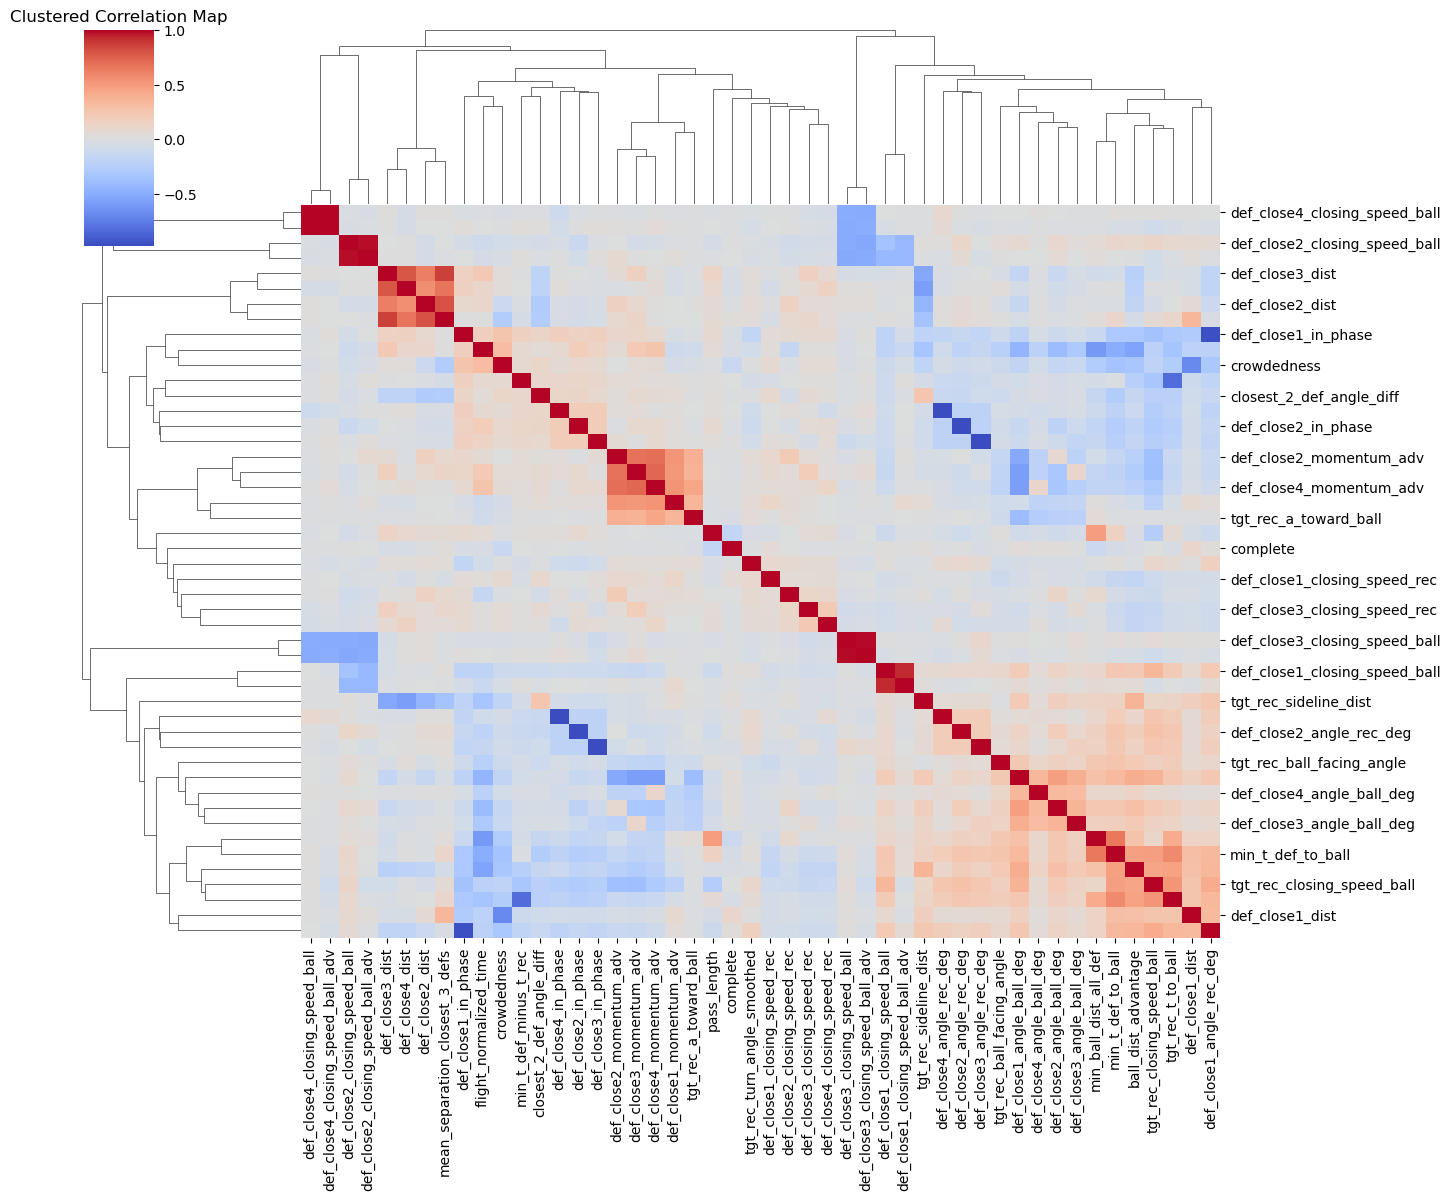

In [17]:
sns.clustermap(df_numeric.corr(), cmap="coolwarm", figsize=(14, 12), annot=False)
plt.title("Clustered Correlation Map")
plt.show()

### Separation Metrics =====

#### tgt_rec_turn_angle_smoothed
How sharply WR changes based on frame to frame change in dir, smoothed on 3 frame rolling averages.

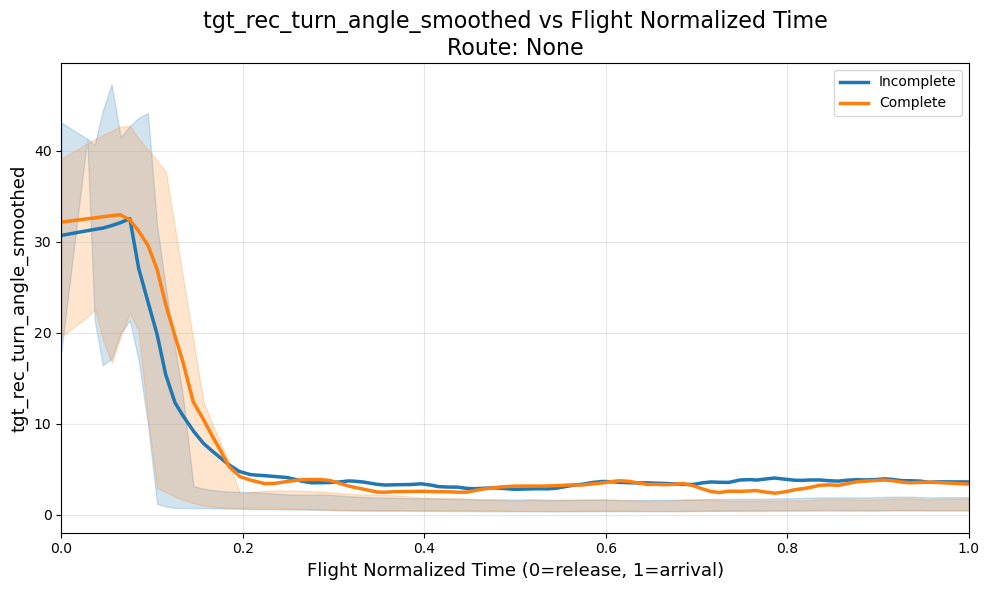

In [7]:
make_time_plot(data_adv, "tgt_rec_turn_angle_smoothed", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### def_close1_dist
How close is the closest defender to the targeted receiver?

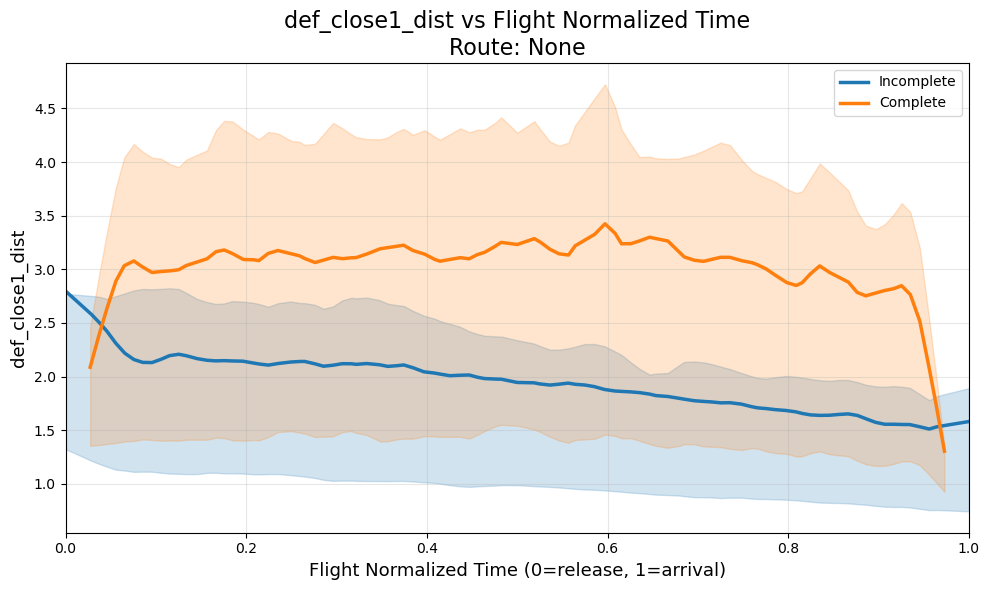

In [8]:
make_time_plot(data_adv, "def_close1_dist", route_group = "VERTICAL")

Remarks:
* In analyzing closest defender distance to receiver, we see the following:
  * GO: Upward separation for completion starting at 0.8
  * POST: Some separation for completion from 0.75 on
  * CORNER: Fair amount of separation for completion from 0.4 on
  * CROSS: Solid amount of separation for completion from 0.7 on
  * IN: Solid amount of separation starting 0.4, biggest between 0.4 and 0.8
  * HITCH: See a jump in separation for completions at 0.85
  * OUT: More separation for completion throughout entire route
  * WHEEL: Weird, less separation indicates completion from 0.35 on
  * SLANT: Quite distinctive behavior, see completion have less distance from 0 to 0.8, where there is a big switch to where completion has much more separation from 0.8 on

Future Investigation:
* Can we dig in more to critical sections where there is distinct separation - ex) Average separation after 0.8 values for completions vs. incompletions compared for GO routes.

#### mean_separation_closest_3_defs
What is the average separation between the receiver and the closest three defenders?

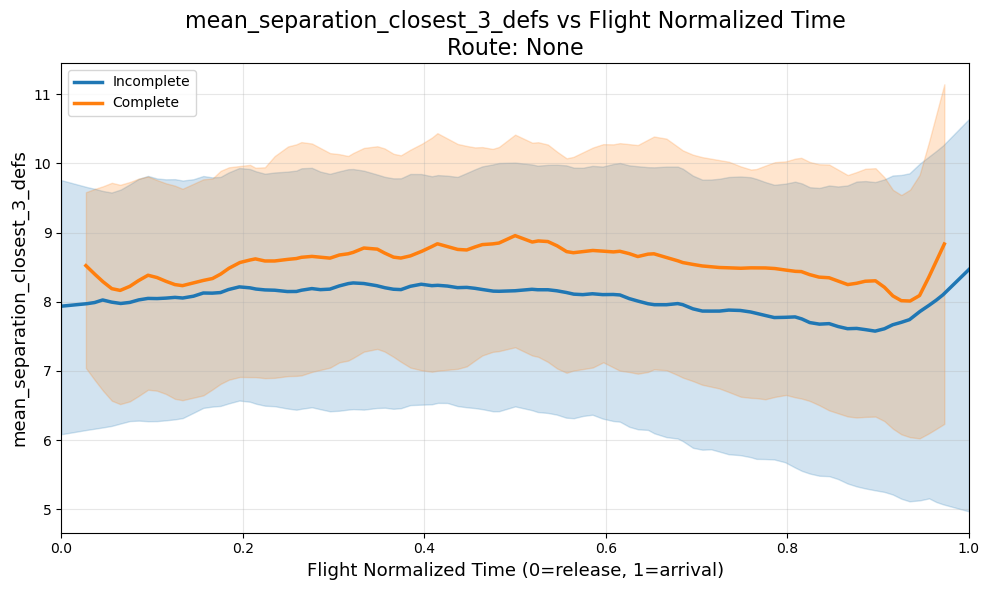

In [9]:
make_time_plot(data_adv, "mean_separation_closest_3_defs", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### crowdedness
Separate metric to measure how crowded a receiver is from other defenders. Higher value indicates more crowded.

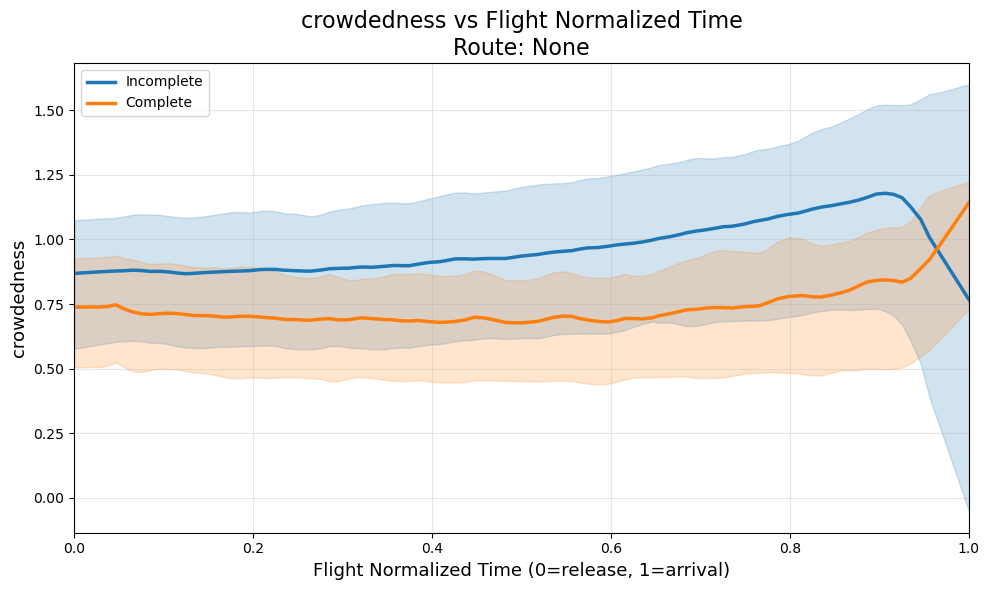

In [10]:
make_time_plot(data_adv, "crowdedness", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: Actually solid separation...
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### def_close1_closing_speed_rec
How fast is the closest defender closing the window to the receiver?

Negative means defender is gaining on receiver, positive means receiver opening gap

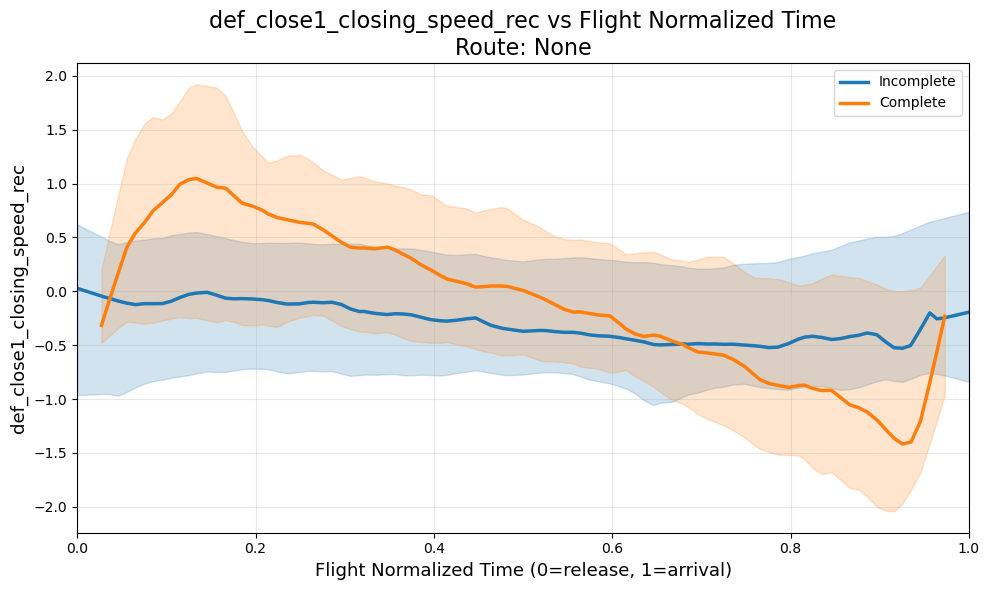

In [11]:
make_time_plot(data_adv, "def_close1_closing_speed_rec", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

### Ball Pursuit Metrics =====

#### tgt_rec_closing_speed_ball
Rate at which window between targeted receiver and ball is closing

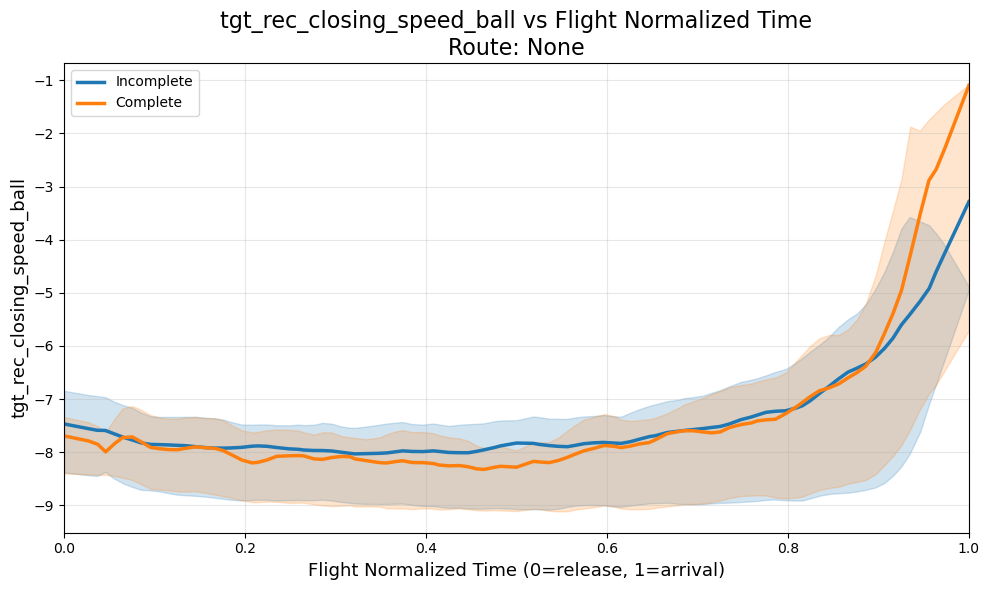

In [23]:
make_time_plot(data_adv, "tgt_rec_closing_speed_ball", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### tgt_rec_t_to_ball
Time from to ball for targeted receiver based on current moving speed and distance.

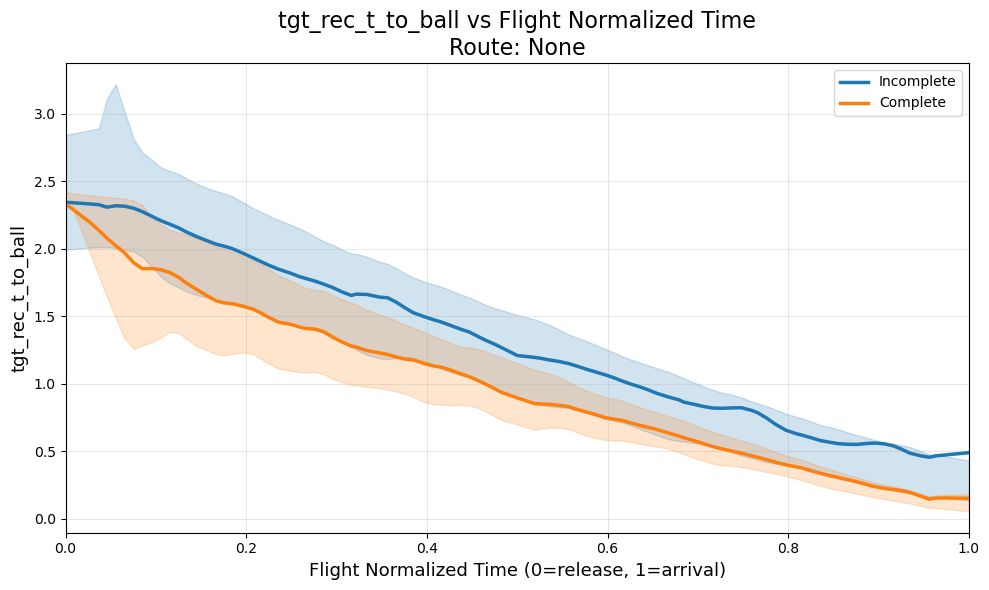

In [12]:
make_time_plot(data_adv, "tgt_rec_t_to_ball", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### tgt_rec_a_toward_ball
Receiver's acceleration component toward ball

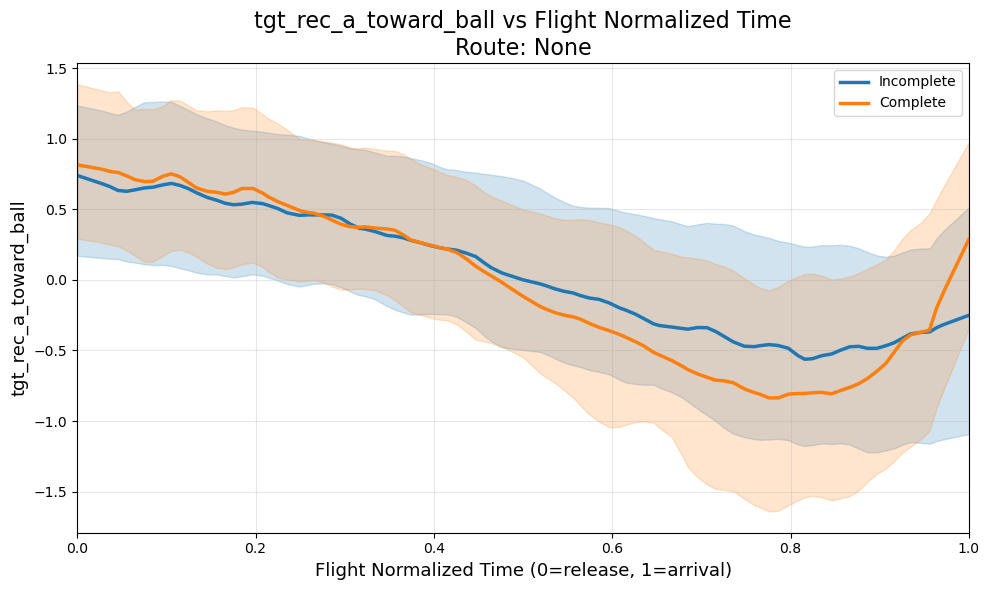

In [13]:
make_time_plot(data_adv, "tgt_rec_a_toward_ball", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### tgt_rec_ball_facing_angle
Angle between where receiver is facing versus vector from WR -> ball

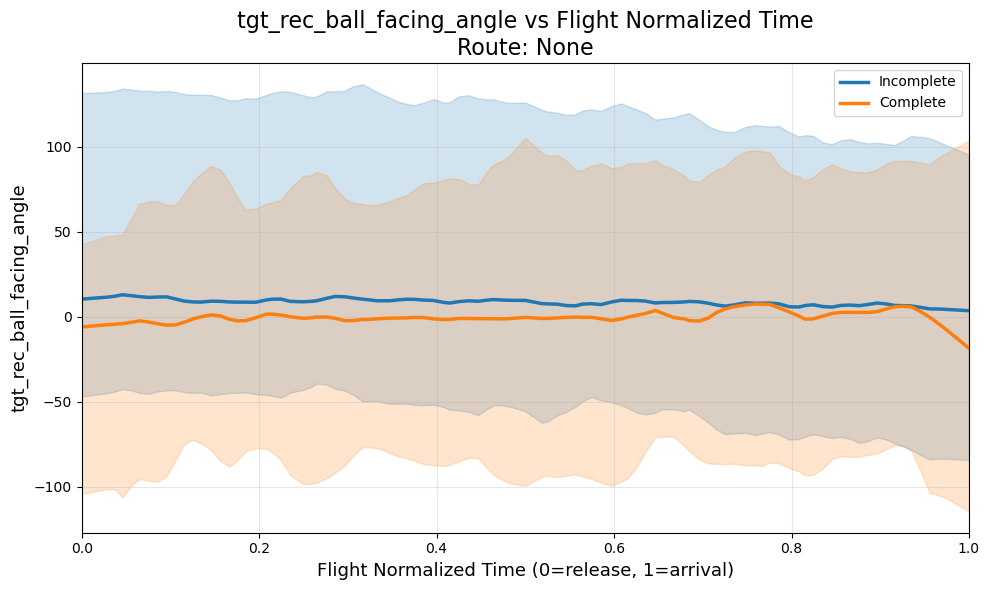

In [14]:
make_time_plot(data_adv, "tgt_rec_ball_facing_angle", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### def_close1_momentum_adv
Difference between the targeted receiver's velocity component toward the ball and that of the nearest defender.

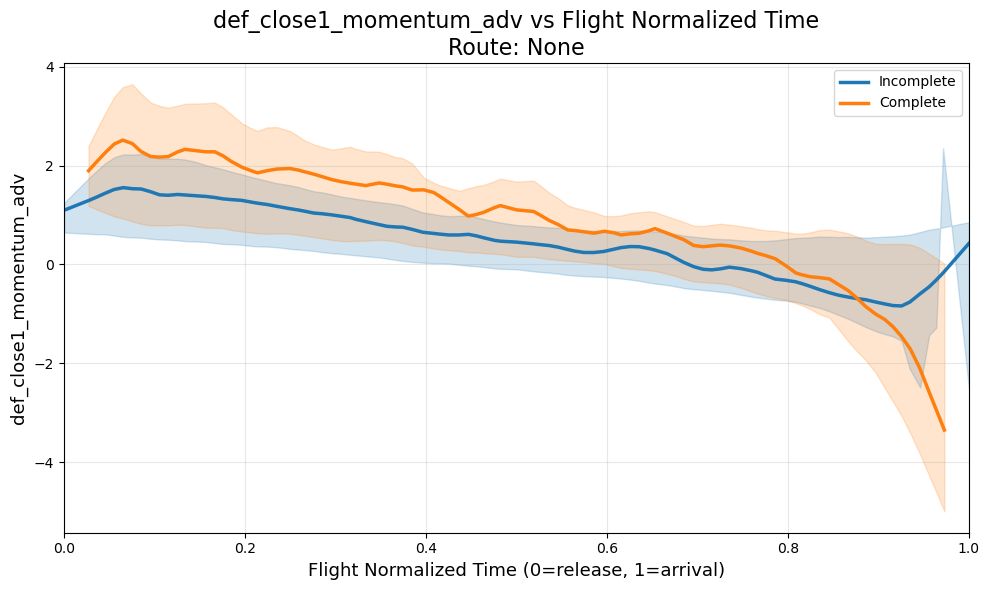

In [15]:
make_time_plot(data_adv, "def_close1_momentum_adv", route_group = "VERTICAL")

Remarks:
* In analyzing initial closest defender:
  * GO: Very similar throughout, small receiver advantage at end for completion
  * POST: Break point potentially ~0.55, where greatest receiver advantage comes up for completion
  * CORNER: Break is more long and drawn out for completion, and post break indicated by favoring DB at end of route
  * CROSS: Potential break point for completions from 0.45-0.6, whereas incompletions just stay consistently a minor advantage to receivers
  * IN: For completions, se a building up to break point at 0.4, from there it 
  * HITCH: Big break sequence peaking from 0.35-0.6, where then DB tries to catch up
  * OUT: Not really sure how to decipher this, but completions tend to send the db catching up starting around 0.25 big time
  * WHEEL: Similar to out, completions tend to send db catching up from 0.2 to around 0.4, where then the WR regains momentum
  * SLANT: Built up to break that happens around 0.3-0.4, then receiver catching up pretty much then on after.

* General behavior:
    * For completions, there is usually some point where the receiver advantage peaks, and that is hypothetically the break point of their route. After that, since the defender is trying to catch up, the advantage generally switches to them.
    * For incompletions, it is kind of the opposite effect. We also see a lot of routes where if there is a consistent advantage, it runs incomplete, the breaks are useful to get open!

* Interesting behavior - almost like saying that if a defender is pursuing the ball at a higher rate then the receiver, it indicates that the defender is behind defensively...

Future Investigation:
* Look into whether there is merit to completion probability based on observed breaks
* For minimal difference statistics, this might just not be meaningful...

#### def_closeN_closing_speed_ball
Rate at which the window between N-th closest defender and ball is closing

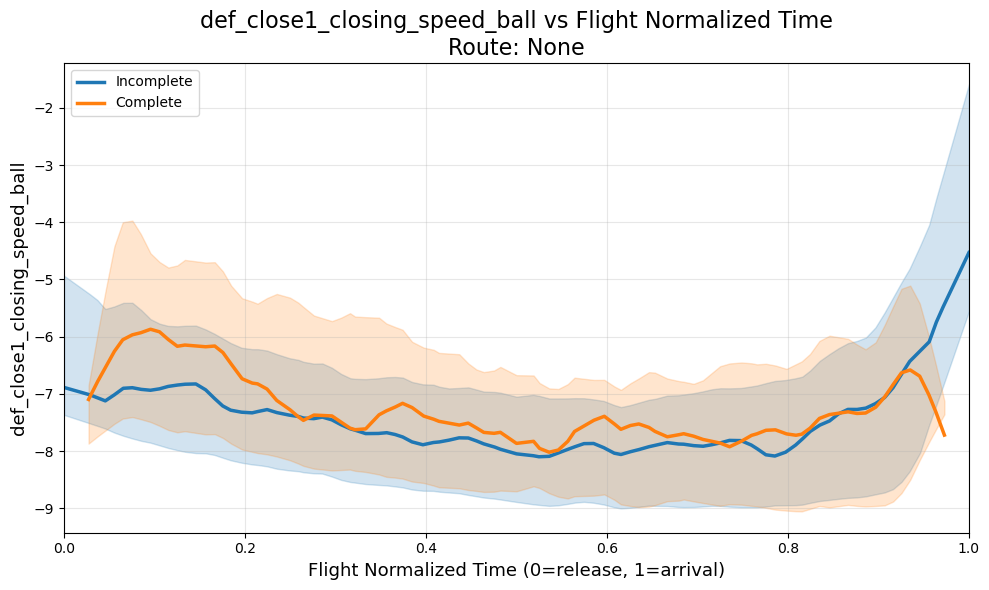

In [16]:
make_time_plot(data_adv, "def_close1_closing_speed_ball", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### def_closeN_closing_speed_ball_adv
In individual form, measures a player's actual movement toward the ball, specifically how quickly they are closing the window between themselves and the ball. The advantage metric measures the difference between the targeted receiver's closing speed toward ball with a defender's closing speed toward ball...

I fixed this to make positive values favor the receiver in closing in on the ball faster than the defender...

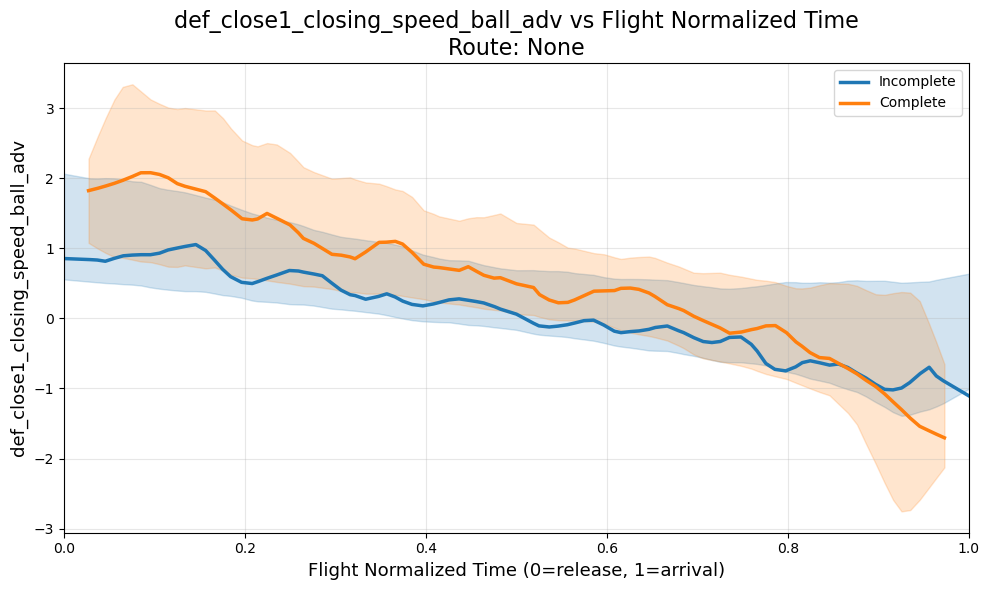

In [29]:
make_time_plot(data_adv, "def_close1_closing_speed_ball_adv", route_group = "VERTICAL")

Remarks:
* In analyzing initial closest defender:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

* These are quite hard to explain based on just looking, but I will say many of these lines are quite distinctive, even though there are crossings. I feel like this could lend to being a good predictor...

Future Investigation:
* 

#### def_closeN_angle_ball_deg
How far is defender off of direct path to ball?

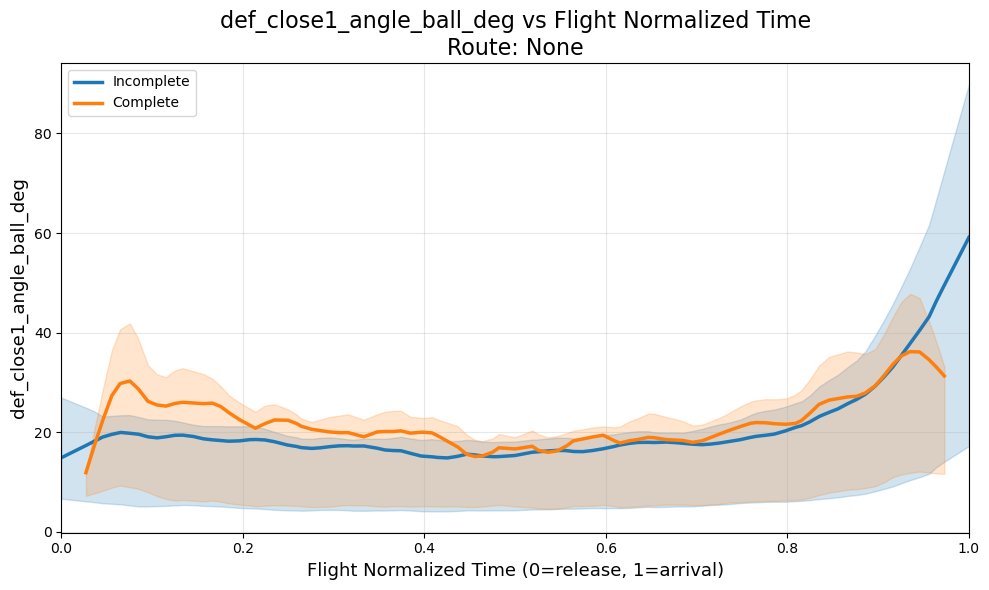

In [17]:
make_time_plot(data_adv, "def_close1_angle_ball_deg", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: Interesting
  * OUT: Somewhat interesting
  * WHEEL: Interesting
  * SLANT: Noisy

Future Investigation:
* 

#### min_ball_dist_all_def
Of all defenders, what is the distance between the ball and defender closest to the ball?

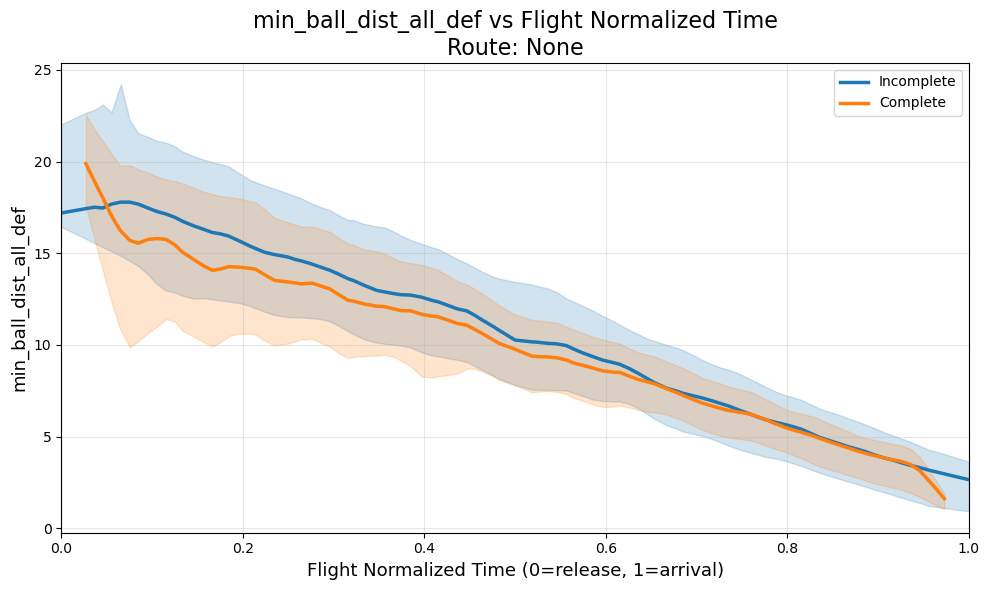

In [18]:
make_time_plot(data_adv, "min_ball_dist_all_def", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### ball_dist_advantage
Targeted receiver's distance from ball minus the closest defender to the ball's distance to the ball.

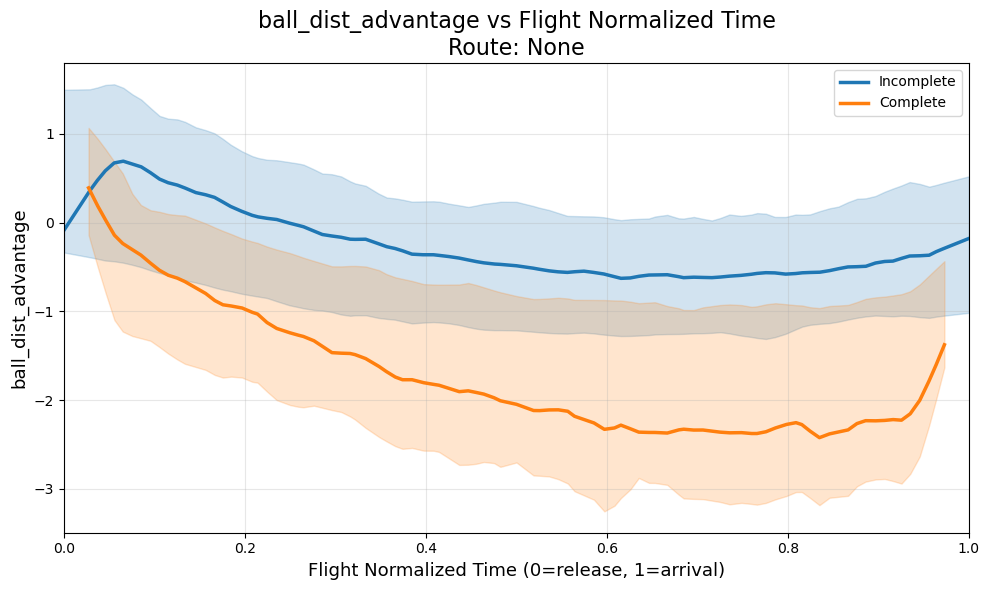

In [32]:
make_time_plot(data_adv, "ball_dist_advantage", route_group = "VERTICAL")

Remarks:
* In analyzing ball distance advantage, we find:
  * GO: Almost identical throughout
  * POST: Almost identical throughout
  * CORNER: Almost identical throughout
  * CROSS: Less advantage for receiver from 0.6 on...
  * IN: Minor advantage for receiver until 0.95
  * HITCH: Receiver advantage till 0.5, then becomes defender's advantage
  * OUT: Weird lump toward db advantage for completions from 0.85 on
  * WHEEL: Receiver advantage till end
  * SLANT: Less receiver advantage throughout

Future Investigation:
* I am very confused at the results of this, may just be meaningless

#### min_t_def_to_ball
Minimum time for a defender to get to ball, based on their current speed and distance from the ball. Essentially min_ball_distance_all_def, but also incorporating movement speed

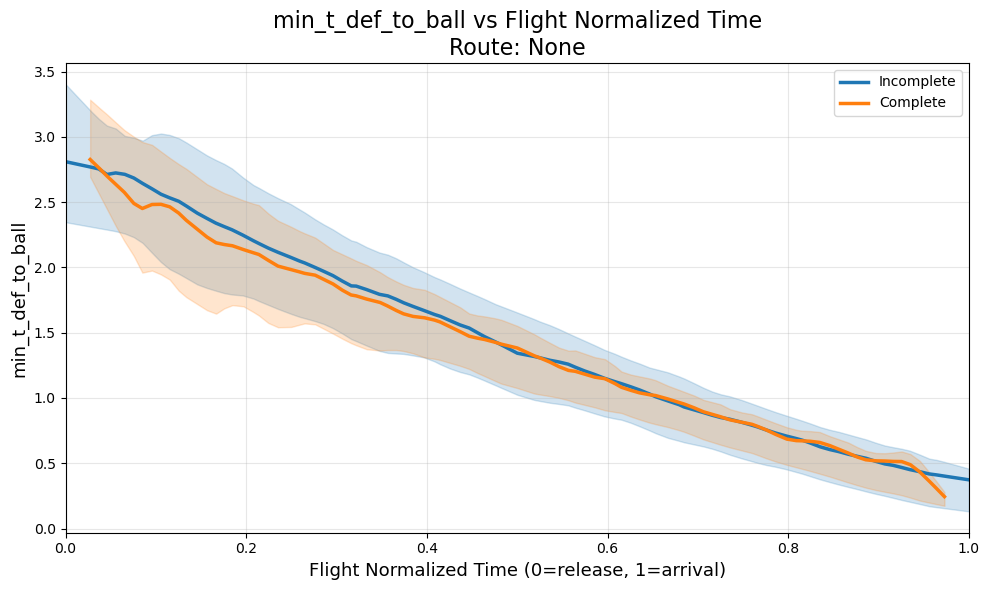

In [19]:
make_time_plot(data_adv, "min_t_def_to_ball", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### min_t_def_minus_t_rec
Difference between minimum time for a defender to get to ball at current speed and distance and that of the targeted receiver. Positive should favor the receiver. Doesn't account for direction, though

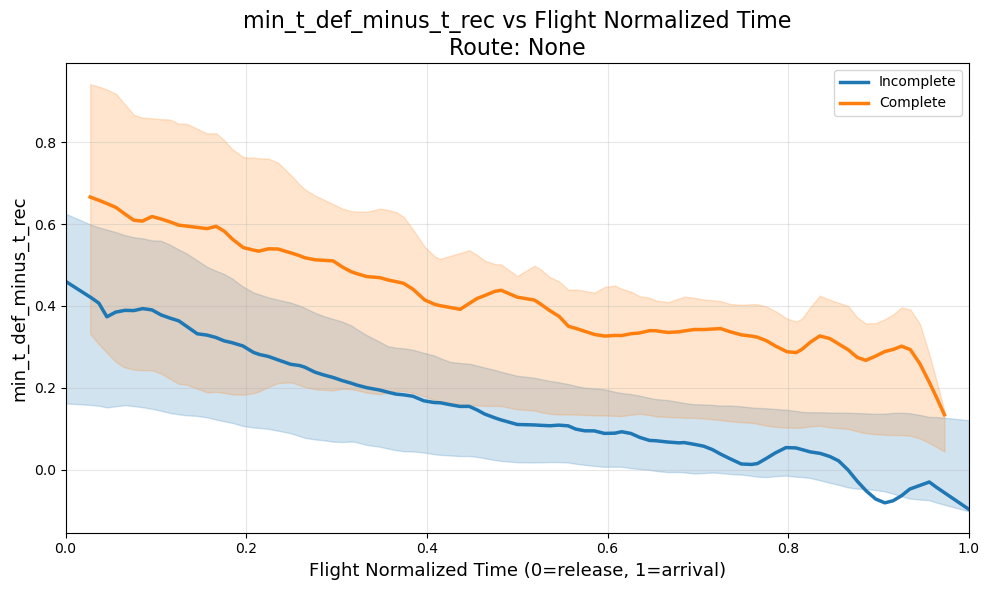

In [20]:
make_time_plot(data_adv, "min_t_def_minus_t_rec", route_group = "VERTICAL")

Remarks:
* In analyzing initial closest defender:
  * GO: Very interesting spike in average data here where it goes to neutral for a second, then goes back to the trend toward neutral... weird
  * POST: Pretty hard to separate...
  * CORNER: Also pretty hard to separate...
  * CROSS: Completion spikes back and forth before settling...?
  * IN: Downward toward advantage receiver, then spikes back up
  * HITCH: 
  * OUT: Spike in favor of receiver
  * WHEEL: Another pretty vivid break at 0.35
  * SLANT: 

* This data does seem kind of weird, I am not sure what to make of it

Future Investigation:
* 

### Angle of Attack Metrics =====

#### def_close1_angle_rec_deg
Angle difference with receiver in their motion. This is almost like angle of attack by defensive players.

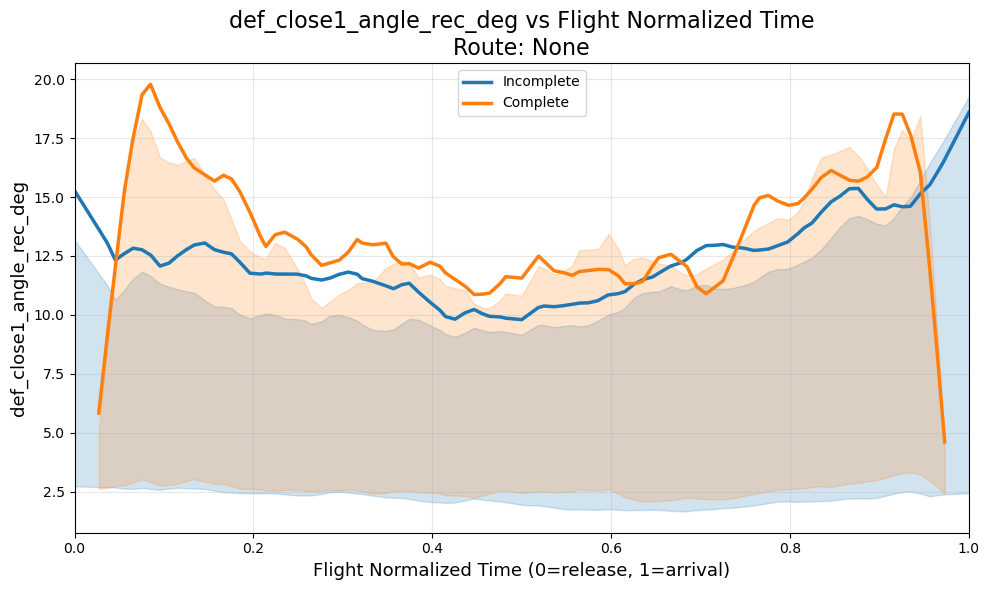

In [35]:
make_time_plot(data_adv, "def_close1_angle_rec_deg", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### def_close1_in_phase
This quantifies how aligned the degree of motion is between defender and receiver... basically anti-correlated with angle_rec_deg...

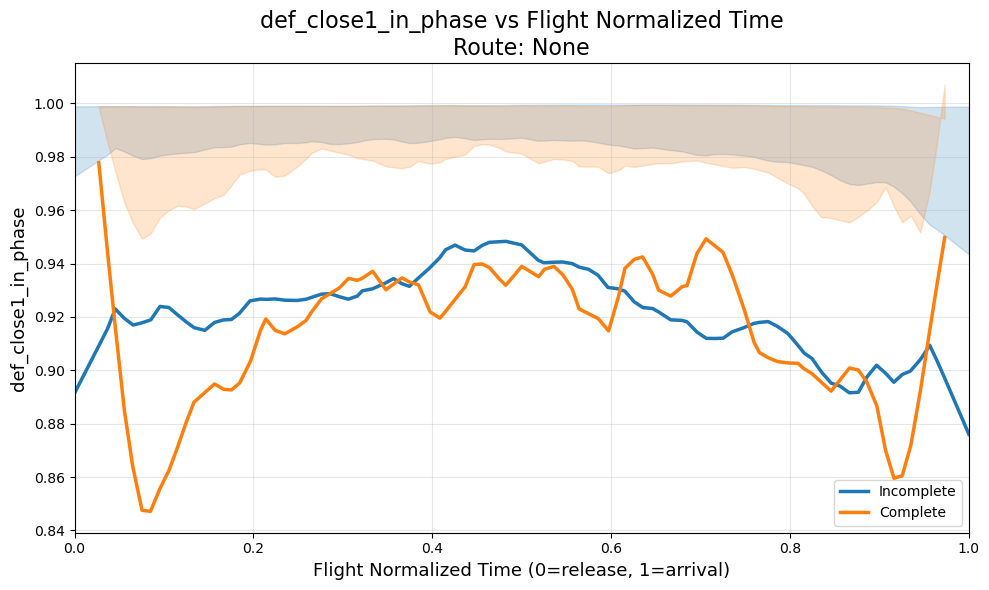

In [36]:
make_time_plot(data_adv, "def_close1_in_phase", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### closest_2_def_angle_diff
Metric analyzing the difference between closest two defenders attack angle to the receiver.

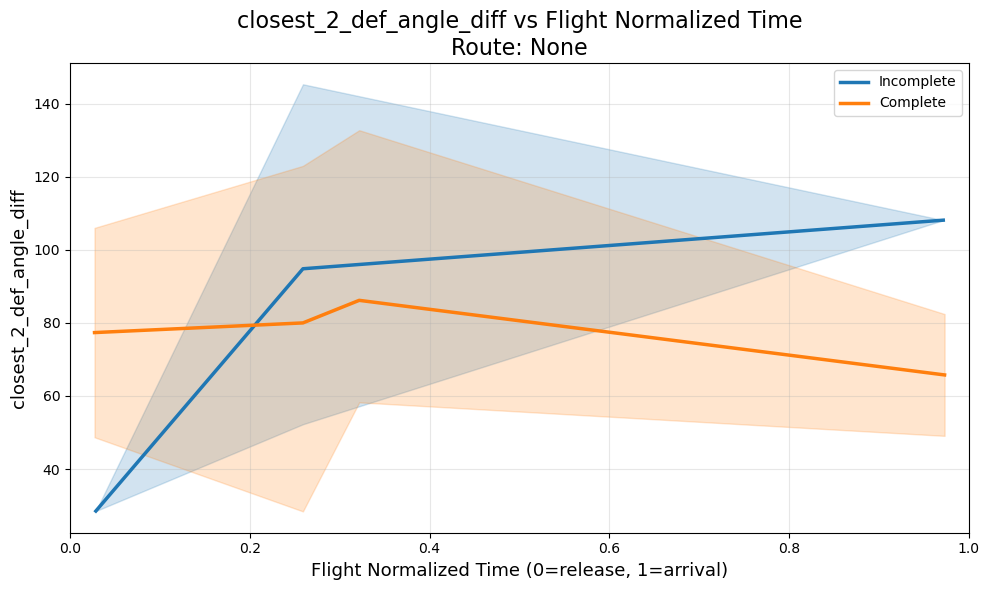

In [37]:
make_time_plot(data_adv, "closest_2_def_angle_diff", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

### Other ====

#### pass_length
Distance beyond the LOS that the ball traveled

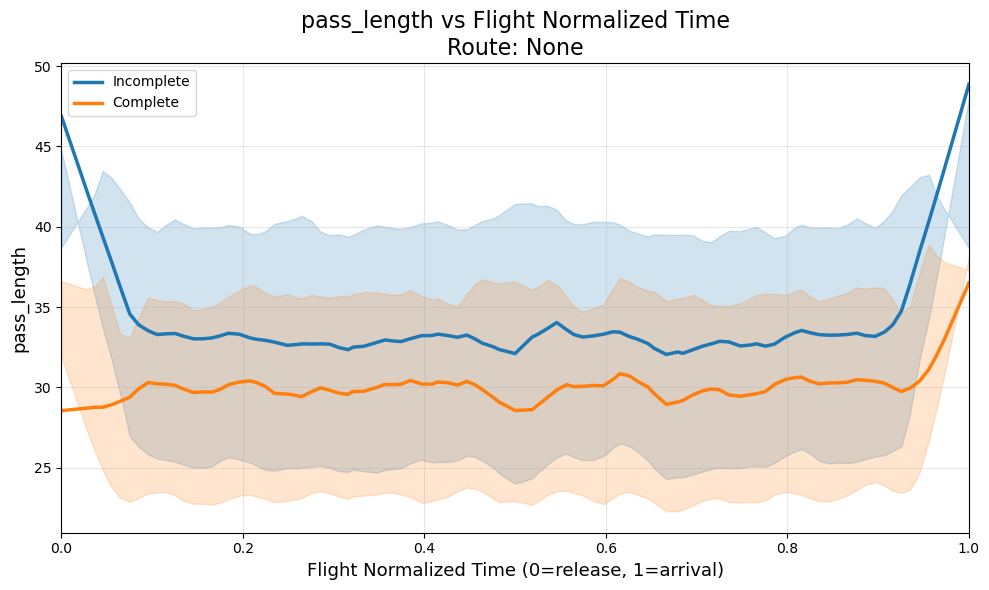

In [38]:
make_time_plot(data_adv, "pass_length", route_group = "VERTICAL")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

#### tgt_rec_sideline_dist
Distance from sideline of targeted receiver

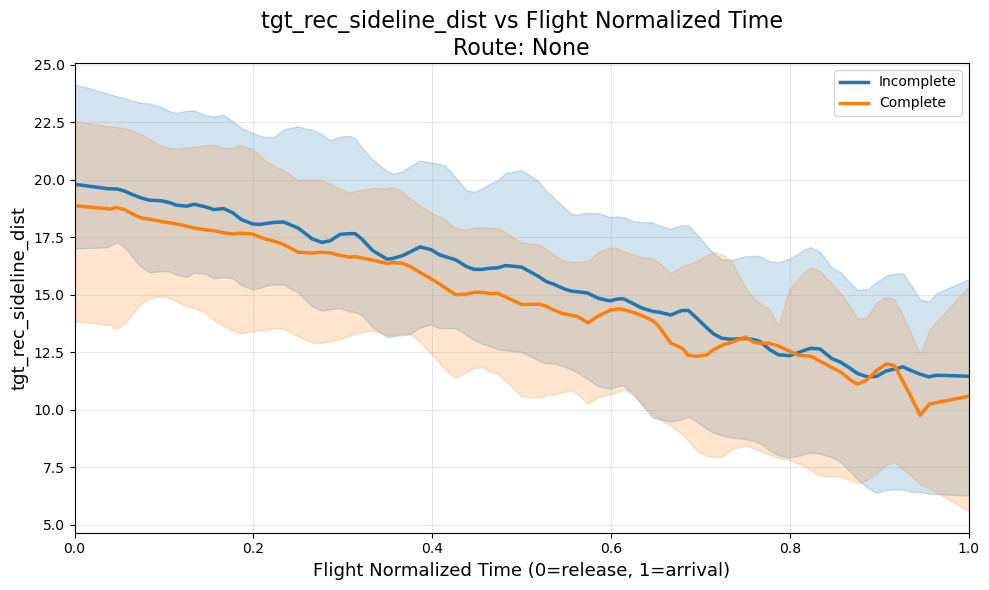

In [39]:
make_time_plot(data_adv, "tgt_rec_sideline_dist", route_group = "INTERMEDIATE")

Remarks:
* In analyzing [metric], we see the following:
  * GO: 
  * POST: 
  * CORNER: 
  * CROSS: 
  * IN: 
  * HITCH: 
  * OUT: 
  * WHEEL: 
  * SLANT: 

Future Investigation:
* 

## Prepare Model Features

In [40]:
# Select Columns for Modeling
id_cols = ['game_id', 'play_id']

cat_cols = ['route_group', 'route_of_targeted_receiver']

num_cols = [
    'flight_normalized_time', 'pass_length', 'complete',
    'def_close1_dist', 'def_close2_dist', 'def_close3_dist', 'def_close4_dist',
    'tgt_rec_closing_speed_ball', 'def_close1_closing_speed_ball', 'def_close2_closing_speed_ball',
    'def_close3_closing_speed_ball', 'def_close4_closing_speed_ball', 'def_close1_closing_speed_ball_adv',
    'def_close2_closing_speed_ball_adv', 'def_close3_closing_speed_ball_adv', 'def_close4_closing_speed_ball_adv',
    'def_close1_momentum_adv', 'def_close2_momentum_adv', 'def_close3_momentum_adv', 'def_close4_momentum_adv',
    'def_close1_closing_speed_rec', 'def_close2_closing_speed_rec', 'def_close3_closing_speed_rec', 'def_close4_closing_speed_rec',
    'mean_separation_closest_3_defs', 'min_ball_dist_all_def', 'ball_dist_advantage',
    'def_close1_angle_rec_deg', 'def_close2_angle_rec_deg', 'def_close3_angle_rec_deg', 'def_close4_angle_rec_deg',
    'def_close1_angle_ball_deg', 'def_close2_angle_ball_deg', 'def_close3_angle_ball_deg', 'def_close4_angle_ball_deg',
    'tgt_rec_t_to_ball', 'min_t_def_to_ball', 'min_t_def_minus_t_rec', 'tgt_rec_ball_facing_angle',
    'tgt_rec_sideline_dist', 'tgt_rec_turn_angle_smoothed', 'crowdedness', 'tgt_rec_a_toward_ball',
    'closest_2_def_angle_diff'
]

model_cols = id_cols + cat_cols + num_cols

df_model = data_adv[data_adv['to_release'] == 'after'].copy()
df_model = df_model[model_cols]

In [41]:
# Make Train / Validation Split
plays = df_model[['game_id', 'play_id']].drop_duplicates()

train_plays, val_plays = train_test_split(plays, test_size = 0.2, random_state = 42)

train_df = df_model.merge(train_plays, on = ['game_id', 'play_id'], how = "inner")

val_df = df_model.merge(val_plays, on = ['game_id', 'play_id'], how = "inner")

print(f"Train frames: {len(train_df)}, Validation frames: {len(val_df)}")

Train frames: 30636, Validation frames: 7722


In [42]:
# Save Train, Val DF's as CSV
train_df.to_csv("train_dataset.csv", index=False)
val_df.to_csv("val_dataset.csv", index=False)